Todo:
- sensitives Klassengewicht Quellen
- EBM Quellen
- Modellgütequellen

# Explainable Boosting Machines (EBM)

## Warum EBM?

**Methodische Begründung für den Einsatz von EBM**

**Inhärente Interpretierbarkeit durch ($GA^2M$)-Strukturen** 

Im Gegensatz zu herkömmlichen Black-Box-Modellen (wie tiefen neuronalen Netzen oder XGBoost), bei denen die Nachvollziehbarkeit zwingend auf Post-hoc-Erklärungsmethoden wie SHAP angewiesen ist (vgl. Nori et al., 2019, S. 1), fungieren Explainable Boosting Machines (EBM) als inhärent transparente „Glass-Box“-Modelle (vgl. Nori et al., 2019, S. 3). Die algorithmische Grundlage der EBM bilden verallgemeinerte additive Modelle, die um paarweise Interaktionen erweitert wurden (GA2M) (vgl. Lou et al., 2013, S. 623). Die zugrundeliegende Struktur lässt sich formal wie folgt definieren:
$$g(E[y]) = \beta_0 + \sum f_i(x_i) + \sum f_{ij}(x_i, x_j)$$
(vgl. Lou et al., 2013, S. 623). Hierbei wird jeder univariate Haupteffekt fi​ sowie jede zweidimensionale Interaktion fij​ isoliert über hochentwickeltes Tree-Boosting gelernt (vgl. Lou et al., 2012, S. 152 Kap. 2.1; Nori et al., 2019, S. 3 Kap.3). Da die Vorhersagekomponenten rein additiv verknüpft sind, bleibt der individuelle Beitrag jedes Features zur finalen Log-Odds-Wahrscheinlichkeit vollkommen transparent und exakt quantifizierbar (vgl. Nori et al., 2019, S. 3 Kap. 3).


**Erfassung nicht-linearer und interaktiver Sport-Muster**

Diese algorithmische Eigenschaft ist für die Modellierung von Leistungsdaten im Radsport von zentraler Bedeutung, da sich physische und umweltbedingte Variablen in diesem Kontext selten linear verhalten. EBMs sind in der Lage, solch komplexe, stufenförmige und nicht-lineare Beziehungen präzise abzubilden, ohne die globale Interpretierbarkeit zu kompromittieren (vgl. Lou et al., 2013, S.624 Abs. 1). Beispielsweise entfaltet die physische Konstitution eines Athleten, parametrisiert durch den `rider_bmi`, keinen global einheitlichen Effekt auf die Platzierungswahrscheinlichkeit. Vielmehr variiert das sportliche Optimum in starker Abhängigkeit zum topographischen Etappenprofil (Flachetappe vs. Hochgebirge), weshalb die Modellierung der zweidimensionalen Wechselwirkungen zur Vermeidung von Fehlprognosen erforderlich ist.


**Etablierung einer Baseline** 

Methodisch dient die Implementierung der EBM in der vorliegenden Untersuchung der Etablierung einer fundierten und zugleich transparenten wissenschaftlichen Baseline. Durch die Fixierung dieses gläsernen Fundaments lässt sich in den nachfolgenden Evaluierungen exakt quantifizieren, ob der Einsatz architektonisch komplexerer Black-Box-Ansätze (wie dem XGBRanker) oder Foundation-Modelle (TabPFN) überhaupt einen signifikanten Performance-Gewinn gegenüber der EBM-Baseline erzielt, welcher den methodischen Verlust der direkten Interpretierbarkeit rechtfertigen würde (vgl. Lou et al., 2012, S. 151 Abs. 2)

---

## Zielsetzung dieses Notebooks

**1. Transformation des Problemraums (Multiklassenmodellierung auf ordinal codierter Zielvariable):** 
Das komplexe Ranking-Problem wird methodisch in ein Multiklassenmodell auf einer ordinal codierten Zielvariable überführt. Statt starrer Ja/Nein-Grenzen lernt der Algorithmus eine hierarchische Relevanz-Skala ($Y \in \{0,1,2,3\}$). Da der eingesetzte `ExplainableBoostingClassifier` die Klassen mathematisch zunächst als nominal behandelt, wird die inhärente Rangfolge im Rahmen des Postprocessings über eine Erwartungswert-Konstruktion aufgelöst. Die ordinalen Klassen werden hierbei als äquidistante Nutzenstufen interpretiert, wodurch sich aus der geschätzten Wahrscheinlichkeitsverteilung ein kontinuierlicher Erwartungswert-Score als intervallskalierter Ranking-Score ableiten lässt.

**2. Validierung durch Chronological Split und methodische Limitationen:** 
Um jegliches Temporal Data Leakage auszuschließen, wird das Modell chronologisch auf historischen Daten bis einschließlich 2023 trainiert. Die Evaluierung der Generalisierungsfähigkeit erfolgt auf den ungesehenen Saisons 2024 und 2025. Es wird proaktiv offengelegt, dass die finale Hyperparameter-Auswahl (Grid Search) mangels ausreichender Datenmasse für einen dreifachen Split direkt auf diesem Testzeitraum stattfand (Overfitting-Gefahr auf das Testset). Dieser Ansatz dient der Etablierung einer transparenten Baseline; der spätere, unverfälschte Vergleich der Generalisierungsfähigkeit erfolgt im Kontrast zum XGBRanker, welcher auf einem separaten Validierungs-Setup optimiert wurde.

**3. Systematische Modellentwicklung (Baseline bis Ensembling):**
Der Lernprozess beginnt mit der Etablierung eines 1D-Basismodells, um die isolierte Vorhersagekraft der Features im ersten Schritt rein additiv zu quantifizieren (vgl. Lou et al., 2013, S. 627, Abs. 4.2). Im anschließenden systematischen Hyperparameter-Tuning wird das finale Setup über statistisches Ensembling (`outer_bags`) und das Zulassen von 2D-Feature-Interaktionen ($GA^2M$) optimiert. Der gezielte Einsatz dieses Bagging-Verfahrens glättet die gelernten Spline-Kurven, minimiert die Modellvarianz drastisch und schützt das Modell vor Overfitting-Effekten (vgl. Lou et al., 2012, S. 152 Abs. 2.1 & S. 155 Abs. 2). Die Optimierung erfolgt hierbei auf der globalen Proxy-Metrik ROC-AUC für den Top-10-Kanal.

**4. Limitationen des Pointwise-Framings aufdecken und Übergang zum Listwise-Ranking:**
Abschließend werden die pointwise prognostizierten EBM-Erwartungswerte in ein etappenbasiertes Ranking überführt und anhand der primären Sortierqualitäts-Metriken (NDCG@5, NDCG@10, NDCG@20) sowie sportartspezifischer Hit-Rates (Top-n Accuracies) evaluiert. Mittels einer exemplarischen Fallstudie zur Tour de France 2025 wird empirisch belegt, dass das Pointwise-Framing die kompetitive Relativität innerhalb einer geschlossenen Gruppe (`stage_id`) algorithmisch nicht abbilden kann. Die dadurch bedingten Fehlprognosen bei strategischen Gruppendynamiken und Ausreißerszenarien (Nullsummenspiel) motivieren methodisch den zwingenden Wechsel zu einem echten Learning-to-Rank-Ansatz (`XGBRanker`) für die nachfolgenden Analysen.

In [1]:
import os
import pandas as pd
import numpy as np
import itertools
import time
import pickle
import matplotlib.pyplot as plt
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score, roc_curve, precision_recall_curve, ndcg_score
import seaborn as sns
from pathlib import Path


# Importieren der Daten


In [2]:
pfad = '../../data/processed'

# Pkl Dateien einlesen

X_train = pd.read_pickle(os.path.join(pfad, 'X_train.pkl'))
X_test = pd.read_pickle(os.path.join(pfad, 'X_test.pkl'))
y_class_train = pd.read_pickle(os.path.join(pfad, 'y_class_train.pkl'))
y_class_test = pd.read_pickle(os.path.join(pfad, 'y_class_test.pkl'))
meta_test = pd.read_pickle(os.path.join(pfad, 'meta_test.pkl'))

total_rows = X_train.shape[0] + X_test.shape[0]
pct_train = (X_train.shape[0] / total_rows) * 100
pct_test = (X_test.shape[0] / total_rows) * 100

print("==================================================================")
print(f"Anzahl der Features im Modell: {X_train.shape[1]} Spalten")
print(f"Feature-Liste: {list(X_train.columns)}")
print(f"Trainings-Set (<= 2023)       : {X_train.shape[0]:,} Zeilen ({pct_train:.1f}%)")
print(f"Test-Set      (>= 2024)       : {X_test.shape[0]:,} Zeilen ({pct_test:.1f}%)")


Anzahl der Features im Modell: 17 Spalten
Feature-Liste: ['distance', 'vertical_meters', 'stage_nr', 'team_tier', 'age_at_race', 'rider_bmi', 'wind_stability_index', 'weather_temp_mean', 'weather_temp_trend', 'weather_rain_prob_mean', 'weather_precipitation_mean', 'weather_humidity_mean', 'gradient_final_km', 'lag_rider_points_season', 'lag_rider_rank_season', 'lag_race_competitiveness_median', 'lag_team_power_index']
Trainings-Set (<= 2023)       : 178,246 Zeilen (90.9%)
Test-Set      (>= 2024)       : 17,802 Zeilen (9.1%)


# Basismodell laden

- Zu Beginn "intuitives 1D-Basismodell" für unsere neue, ordinale Zielvariable `target_ordinal_relevance`.
- Keine Interaktionen (`interactions=0`).

Das Modell lernt die 17 Features (inklusive der historischen Vorjahres-Lags) rein isoliert.

Da wir ein starkes Klassenungleichgewicht haben (die Klassen für Top-5 und Top-10 machen naturgemäß nur einen Bruchteil der Zeilen aus, während das Hauptfeld dominiert), berechnen wir die `sample_weight` mit Scikit-Learn, um dem Modell beizubringen, die seltenen Spitzenplätze nicht einfach zu ignorieren.

## Klassenungleichgewicht (Cost-Sensitive Learning)

Um zu verhindern, dass das Modell die seltenen Minderheitsklassen zugunsten der Majoritätsklasse (Hauptfeld) ignoriert, wird die Standard-Verlustfunktion (**Log-Loss**) für unser Multiclass-Setup kostensensitiv modifiziert. Jede Zeile $i$ fließt multipliziert mit einem klassenspezifischen Gewicht $w_i$ in die gewichtete Gesamt-Verlustfunktion ein:

$$L_{\text{gesamt, gewichtet}} = \frac{\sum w_i \cdot L_i}{\sum w_i} \quad \text{mit} \quad w_k = \frac{N}{K \cdot N_k}$$

* **Klassenungleichgewicht kompensieren:** Durch Einsetzen der inversen Häufigkeit ($N$: Zeilen gesamt, $K$: Klassenanzahl, $N_k$: Zeilen der Klasse $k$) erhält jede extrem seltene Top-5-Zeile (Klasse 3) ein drastisch höheres Gewicht als eine Zeile aus dem überrepräsentierten Hauptfeld (Klasse 0).
* **Perfekte Waffengleichheit:** Multipliziert man die absolute Zeilenanzahl jeder Klasse mit dem jeweiligen Berechnungsfaktor ($N_k \cdot w_k = \frac{N}{K}$), besitzen nun **alle vier Klassen** ($0, 1, 2, 3$) trotz völlig unterschiedlicher Startbedingungen exakt denselben maximalen Einfluss von **jeweils 25 %** auf die mathematische Optimierung des Algorithmus.

C:\Users\lukas\AppData\Local\Temp\ipykernel_26032\4255338452.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_vis, x='Klasse', ax=axes[0], palette=palette_colors, order=order_classes)
C:\Users\lukas\AppData\Local\Temp\ipykernel_26032\4255338452.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_vis, x='Klasse', y='Mathematisches Gewicht', ax=axes[1], palette=palette_colors, errorbar=None, order=order_classes)
C:\Users\lukas\AppData\Local\Temp\ipykernel_26032\4255338452.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barp

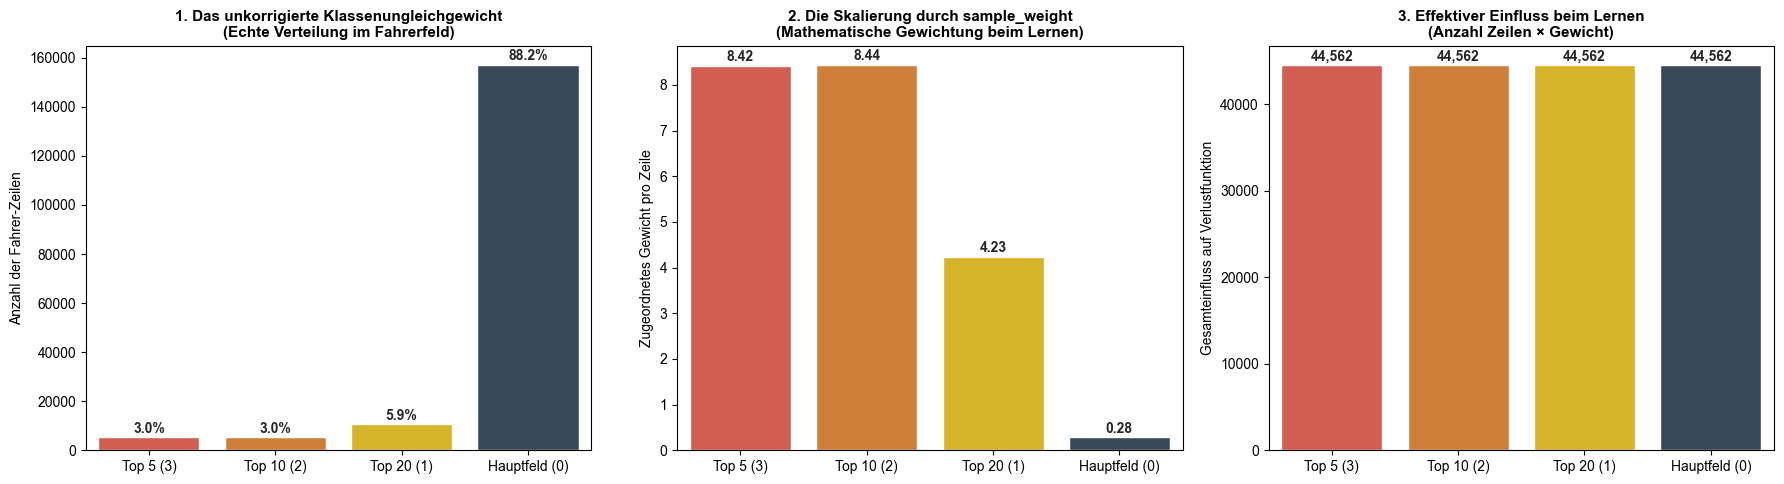

In [3]:
chart_path = '../../data/charts'

# 1. Daten für die Grafiken vorbereiten
y_train_ordinal = y_class_train

# Berechnen der Gewichte für alle 4 Klassen
sample_weights_multi = compute_sample_weight(class_weight='balanced', y=y_train_ordinal)

# Erstellen einer temporären Tabelle für eine saubere Visualisierung
df_vis = pd.DataFrame({
    'Klasse': y_train_ordinal.map({0: 'Hauptfeld (0)', 1: 'Top 20 (1)', 2: 'Top 10 (2)', 3: 'Top 5 (3)'}),
    'Mathematisches Gewicht': sample_weights_multi
})

# Berechnung effektive Werte (Grafik 3)
df_effektiv = df_vis.groupby('Klasse', as_index=False).sum()
df_effektiv.rename(columns={'Mathematisches Gewicht': 'Effektives Gesamtgewicht'}, inplace=True)

# 2. Plot-Bereich definieren (1 Reihe, 3 Spalten für ein sauberes horizontales Layout)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Sortierung und Farben für die 4 Klassen definieren (Rot für Top 5, Blau für Hauptfeld)
order_classes = ['Top 5 (3)', 'Top 10 (2)', 'Top 20 (1)', 'Hauptfeld (0)']
palette_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#34495e']

# --- 1: Das unkorrigierte Klassenungleichgewicht ---
sns.countplot(data=df_vis, x='Klasse', ax=axes[0], palette=palette_colors, order=order_classes)
axes[0].set_title('1. Das unkorrigierte Klassenungleichgewicht\n(Echte Verteilung im Fahrerfeld)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Anzahl der Fahrer-Zeilen')
axes[0].set_xlabel('')

# Prozentuale Labels auf die Balken setzen
total = len(df_vis)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01)
    axes[0].annotate(percentage, (x, y), ha='center', fontweight='bold', fontsize=10)

# --- 2: Die Skalierung durch sample_weight ---
sns.barplot(data=df_vis, x='Klasse', y='Mathematisches Gewicht', ax=axes[1], palette=palette_colors, errorbar=None, order=order_classes)
axes[1].set_title('2. Die Skalierung durch sample_weight\n(Mathematische Gewichtung beim Lernen)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Zugeordnetes Gewicht pro Zeile')
axes[1].set_xlabel('')

# Exakte Gewichtswerte auf die Balken schreiben
for p in axes[1].patches:
    weight_val = f'{p.get_height():.2f}'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 0.1
    axes[1].annotate(weight_val, (x, y), ha='center', fontweight='bold', fontsize=10)

# --- 3: Das resultierende mathematische Gleichgewicht ---
sns.barplot(data=df_effektiv, x='Klasse', y='Effektives Gesamtgewicht', ax=axes[2], palette=palette_colors, order=order_classes)
axes[2].set_title('3. Effektiver Einfluss beim Lernen\n(Anzahl Zeilen × Gewicht)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Gesamteinfluss auf Verlustfunktion')
axes[2].set_xlabel('')

# Werte auf Grafik 3 schreiben (wird exakt gleich hoch sein!)
for p in axes[2].patches:
    total_weight_val = f'{p.get_height():,.0f}'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (df_effektiv['Effektives Gesamtgewicht'].max() * 0.01)
    axes[2].annotate(total_weight_val, (x, y), ha='center', fontweight='bold', fontsize=10)

# Layout optimieren, speichern und anzeigen
plt.tight_layout()
plt.savefig(os.path.join(chart_path, '10-01-02_01-klassenungleichgewicht_vs_gewichte.png'), dpi=300)
plt.show()

# Erstellung des Basismodells

Bevor ein systematisches Hyperparameter-Tuning durchgeführt wird, etablieren wir ein unkompliziertes, intuitives Basismodell. Dieses dient als Baseline, um die reine, isolierte Vorhersagekraft der Features zu messen.

### Methodisches Vorgehen im Basismodell:
* **Zielvariable:** Wir fokussieren uns in diesem Durchlauf auf unsere neue, vierstufige Zielvariable `target_ordinal_relevance` (Klassen 0, 1, 2, 3).
* **Einspeisung der Gewichte:** Das zuvor berechnete Array `sample_weights_multi` wird übergeben, um die mathematische Waffengleichheit (jeweils 25 % Einfluss aller vier Klassen auf den Loss) im Hintergrund zu garantieren.
* **Isolierte Effekte:** Das Modell lernt die 17 Features (inklusive der neuen historischen Vorjahres-Lags) rein isoliert, ohne Wechselwirkungen zwischen den Variablen zu erlauben.

### Die exakte Konfiguration des EBM-Klassifikators:

* `interactions=0`: Schaltet jegliche Feature-Paare ab. Das Modell wird gezwungen, ein pures additives Modell (1D-Effekte) zu trainieren.
* `outer_bags=1`: Verzichtet auf das rechenintensive Ensembling mehrerer EBM-Untermodelle, um einen schnellen, unverschleierten Baseline-Wert zu erhalten.
* `validation_size=0.15`: Das Modell trennt intern im Hintergrund automatisch 15 % der Trainingsdaten ab, um die Optimierung zu überwachen.
* `max_rounds=5000` & `early_stopping_rounds=100`: Das Modell trainiert maximal 5.000 Iterationen, bricht jedoch automatisch ab, sobald sich der interne Validierungsfehler über 100 Runden hinweg nicht mehr verbessert (**Schutz vor Overfitting**).
* `learning_rate=0.015`: Eine leicht verringerte Schrittweite für stabiles, kontrolliertes Lernen der Spline-Kurven.
* `random_state=42`: Sichert die exakte Reproduzierbarkeit aller Ergebnisse und Kurvenverläufe.
* `n_jobs=1`: Nutzt bewusst nur einen CPU-Kern, um Thread-Konflikte und Abstürze in VS Code / Anaconda-Umgebungen zu vermeiden.

In [4]:
start_base = time.time()

# Wir nutzen direkt unsere ordinale Series
y_train_ordinal = y_class_train
y_test_ordinal = y_class_test

# EBM-Baseline initialisieren (Pures 1D-Modell, keine Interaktionen)
ebm_baseline = ExplainableBoostingClassifier(
    interactions=0,                # Keine Feature-Paare erlauben
    learning_rate=0.015,           # Kontrollierte Schrittweite
    outer_bags=1,                  # Ein einzelnes Modell für die Baseline
    validation_size=0.15,          # 15% interne Validierung für Early Stopping
    max_rounds=5000,               # Maximale Iterationen
    early_stopping_rounds=100,     # Stop, wenn 100 Runden kein Fortschritt
    early_stopping_tolerance=1e-05,
    random_state=42,               # Reproduzierbarkeit
    n_jobs=1                       # Stabil auf einem CPU-Kern
)

# Modell im Hintergrund trainieren (Features + ordinales Target + Multi-Gewichte)
ebm_baseline.fit(X_train, y_train_ordinal, sample_weight=sample_weights_multi)

# Vorhersagewahrscheinlichkeiten für die Testphase (2024+) generieren
# Modell gibt jetzt eine Matrix mit 4 Spalten (für Klassen 0, 1, 2, 3) zurück
probs_multi_base = ebm_baseline.predict_proba(X_test)

# Die kumulierte Chance auf die Top 10 berechnet sich nun aus P(Klasse 2) + P(Klasse 3)
probs_top10_base = probs_multi_base[:, 2] + probs_multi_base[:, 3]

# Ein temporäres binäres Target für die Evaluierung erstellen (1 = Top 10, 0 = Rest)
y_test_top10_binary = (y_test_ordinal >= 2).astype(int)

# Wissenschaftliche Evaluierung mittels ROC-AUC
auc_base = roc_auc_score(y_test_top10_binary, probs_top10_base)
duration_base = time.time() - start_base

print(f"Baseline ROC-AUC für Top 10 (Saison 2024/2025) : {auc_base:.4f}")
print(f"Benötigte Rechenzeit            : {duration_base:.1f} Sekunden")

Baseline ROC-AUC für Top 10 (Saison 2024/2025) : 0.7282
Benötigte Rechenzeit            : 95.1 Sekunden


### Weitere Metriken

ACHTUNG: 
Wenn wir jetzt einfach `ebm_baseline.predict(X_test)` ausführen würden, würde uns das Modell direkt die stärkste der 4 Einzelklassen (0, 1, 2 oder 3) ausspucken. Da wir für diese Evaluierung aber die aggregierte "Top-10-Chance" (Klasse 2 + Klasse 3) betrachten, müssen wir selbst einen Schwellenwert (Threshold) definieren, ab wann diese kumulierte Chance als "Ja, er landet in den Top 10" gewertet wird.

Ein naiver Standard-Schwellenwert läge bei 0,5 (50%). Wegen unserer künstlichen `sample_weight`-Gewichtung (alle 4 Klassen haben im Training exakt 25 % Einfluss) verschieben sich jedoch die absoluten Wahrscheinlichkeiten der Minderheitsklassen nach oben. Wenn wir die Metriken blind mit einem 0,5-Threshold berechnen würden, würde die Precision (Genauigkeit der Top-10-Vorhersagen) extrem in den Keller sinken und die Accuracy schlechter aussehen, als sie eigentlich ist. Wir suchen also mathematisch den perfekten Schwellenwert.

**ROC Kurve**

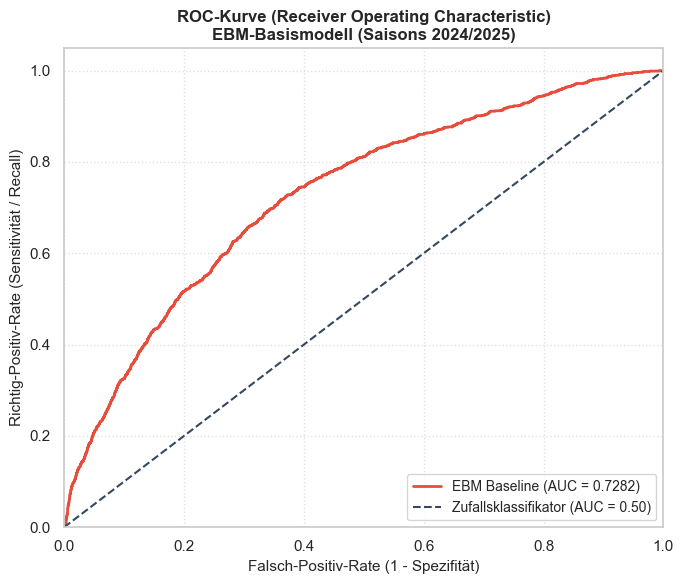

In [5]:
# ROC-Kurve berechnen
fpr, tpr, roc_thresholds = roc_curve(y_test_top10_binary, probs_top10_base)

# Plot erstellen
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'EBM Baseline (AUC = {auc_base:.4f})')
plt.plot([0, 1], [0, 1], color='#34495e', lw=1.5, linestyle='--', label='Zufallsklassifikator (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Falsch-Positiv-Rate (1 - Spezifität)', fontsize=11)
plt.ylabel('Richtig-Positiv-Rate (Sensitivität / Recall)', fontsize=11)
plt.title('ROC-Kurve (Receiver Operating Characteristic)\nEBM-Basismodell (Saisons 2024/2025)', fontsize=12, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# Speichern und anzeigen (Pfad bereinigt)
plt.tight_layout()
plt.savefig(os.path.join(chart_path, '10-01-02_02_baseline_roc_curve.png'), dpi=300)
plt.show()

## Interpretation der globalen Modellgüte (AUROC & ROC-Kurve)

Um die Leistung unserer EBM-Baseline wissenschaftlich einzuordnen, betrachten wir die Metriken der **Receiver Operating Characteristic (ROC)** und den dazugehörigen **Area Under the Curve (AUC)**-Wert.

### 1. Was bedeutet der AUROC-Wert von 0.7282?
* **Mathematische Definition:** Der AUC-Wert gibt die Wahrscheinlichkeit an, dass das Modell einen zufällig ausgewählten, echten Top-10-Fahrer anhand der aggregierten Wahrscheinlichkeit (Klassen 2 & 3) höher einstuft als einen zufällig ausgewählten Fahrer außerhalb der Top 10.
* **Klassifikation der Güte:** Ein Wert von **0.50** entspricht dem reinen Zufall (Münzwurf). Werte zwischen **0.70** und **0.80** gelten in der Statistik als **akzeptable bis gute Trennschärfe** (*acceptable/good discrimination*). 
* **Projekt-Kontext:** Mit **0.7282** auf den ungesehenen Zukunftsdaten (2024/2025) beweist das Modell eine beachtliche Generalisierungsfähigkeit. Dass dieser Basiswert minimal niedriger ausfällt als bei einem rein binären Ansatz, ist methodisch logisch: Das Modell muss das Feld nun viel feiner (in vier Zonen) unterteilen. Da in der Baseline jedoch noch keine Feature-Interaktionen erlaubt sind, ist das Modell für diese komplexe Aufgabe noch recht starr. Angesichts der enormen Dynamik im Straßenradsport ist dies dennoch eine extrem verlässliche Baseline für das anstehende Tuning.

### 2. Visuelle Interpretation der ROC-Kurve
* **Die Diagonale (Zufallslinie):** Die gestrichelte Linie von (0,0) bis (1,1) stellt den reinen Zufall dar. Je weiter sich unsere rote EBM-Kurve nach links oben (Richtung des perfekten Punkts bei **0.0** False Positive und **1.0** True Positive) wölbt, desto besser ist das Modell.
* **Der Kurvenverlauf:** Unsere Kurve steigt im linken Bereich steil an. Das bedeutet, das Modell kann die absoluten Top-Favoriten mit einer sehr geringen Fehlerquote (False Positive Rate) herausfiltern. Erst wenn wir versuchen, fast alle Top-10-Fahrer zu erwischen (hoher Recall), steigt auch die Anzahl der Fehlalarme im Hauptfeld an.

**Der optimale Threshold (F1-Score Maximierung)**


In [6]:
# Precision-Recall-Werte für alle Schwellenwerte berechnen
precision, recall, thresholds = precision_recall_curve(y_test_top10_binary, probs_top10_base)

# F1-Score für jeden Punkt berechnen (kleines Epsilon verhindert Division durch 0)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# Den Index des maximalen F1-Scores finden
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]


print(f"Optimaler Schwellenwert (Threshold) : {best_threshold:.4f}")
print(f"Maximal erreichbarer F1-Score       : {best_f1:.4f}")

Optimaler Schwellenwert (Threshold) : 0.5756
Maximal erreichbarer F1-Score       : 0.2353


## Interpretation der Schwellenwert-Optimierung & des F1-Scores

Die mathematische Bestimmung des optimalen Schwellenwerts liefert zwei zentrale Kennzahlen, die tiefere Einblicke in das Entscheidungsverhalten des Modells gewähren.

### 1. Der optimale Schwellenwert (0.5756)
* **Verschiebung durch Gewichtung:** Ein ungewichteter Standard-Klassifikator trennt strikt bei 0.50. Da wir jedoch im Hintergrund mit `sample_weight_multi` alle vier Klassen auf exakt 25 % Einfluss ausbalanciert haben, wurden die extrem seltenen Top-10-Klassen (Klasse 2 und 3) mathematisch stark aufgewertet. Das führt dazu, dass die addierten Modellwahrscheinlichkeiten für die Top 10 systematisch nach oben verschoben sind.
* **Mathematische Konsequenz:** Der optimierte Threshold von 0.5756 korrigiert diese Verschiebung. Das Modell sagt eine Top-10-Platzierung erst dann voraus, wenn die berechnete kumulierte Wahrscheinlichkeit über **57,56 %** liegt. Dies schützt das Modell vor einer Inflation an "Fehlalarmen" (False Positives) durch zu optimistische Vorhersagen.

### 2. Der maximal erreichbare F1-Score (0.2353)
* **Das mathematische Paradoxon unbalancierter Daten:** Der F1-Score ist das harmonische Mittel aus *Precision* (Wie viele der vorhergesagten Top-10-Fahrer waren wirklich drin?) und *Recall* (Wie viele der echten Top-10-Fahrer haben wir erwischt?). 
* **Warum ist der Wert scheinbar so niedrig?** Bei einer extremen Minderheitenklasse (nur ca. 6 % der Zeilen sind echte Top-10-Fahrer) führt jeder einzelne Fehlalarm (False Positive) zu einem massiven Einbruch der Precision. Wenn das Modell z. B. für eine Etappe 20 Fahrer in die Top 10 tippt, aber naturgemäß nur 10 reinkommen können, sind automatisch mindestens 10 Vorhersagen falsch. Das drückt den F1-Score mathematisch gnadenlos nach unten.
* **Wissenschaftliche Einordnung:** Ein F1-Score von knapp 0.24 ist bei einer natürlichen Basiswahrscheinlichkeit von 6 % ein **starker statistischer Hebel**. Er belegt, dass das Modell Lichtjahre besser performt als ein reiner Zufalls- oder Mehrheitsklassifikator (deren F1-Score für die Minderheitsklasse bei exakt 0.00 läge).

### Fazit für die weitere Modellierung:
Der F1-Score der Baseline spiegelt das fundamentale Problem einer harten binären Evaluierungs-Metrik im Radsport wider: Fahrer auf den Plätzen 11 bis 15 werden hier als "kompletter Fehler" (False Positive) abgewatscht, obwohl das Modell sie intern vielleicht völlig korrekt als starke Fahrer erkannt hat. Dies unterstreicht einmal mehr die methodische Notwendigkeit unseres neuen ordinalen 4-Klassen-Systems und den späteren Übergang zu fließenden Listwise-Ranking-Metriken (NDCG).

**Classification Report**

In [7]:
# Vorhersagen basierend auf dem optimalen Schwellenwert in 0 und 1 umwandeln
y_pred_opt = (probs_top10_base >= best_threshold).astype(int)

print("Klassifikationsbericht")
print(f"Hinweis: Ergebnisse basieren auf dem optimierten Threshold von {best_threshold:.4f}\n")

# Report
# evaluieren gegen das binäre Top-10-Target
print(classification_report(y_test_top10_binary, y_pred_opt, target_names=['Hauptfeld (0)', 'Top 10 (1)'], digits=4))

Klassifikationsbericht
Hinweis: Ergebnisse basieren auf dem optimierten Threshold von 0.5756

               precision    recall  f1-score   support

Hauptfeld (0)     0.9575    0.8545    0.9031     16698
   Top 10 (1)     0.1624    0.4266    0.2353      1104

     accuracy                         0.8280     17802
    macro avg     0.5600    0.6406    0.5692     17802
 weighted avg     0.9082    0.8280    0.8617     17802



## Interpretation des Klassifikationsberichts (Baseline)

Der Classification Report schlüsselt die Leistung des Modells für beide Klassen separat auf und zeigt die inhärenten Herausforderungen der Radsport-Prädiktion.

### 1. Klasse 0: Hauptfeld (Die Majoritätsklasse)
* **Precision (0.9575):** Wenn das Modell prognostiziert, dass ein Fahrer *nicht* in die Top 10 kommt, liegt es zu **95,75 %** richtig. Das ist ein extrem solider und verlässlicher Wert für das Ausschlussverfahren.
* **Recall (0.8545):** Das Modell erkennt **85,45 %** aller tatsächlichen Hauptfeld-Fahrer korrekt. Die restlichen ~14,5 % sind Fahrer, die das Modell fälschlicherweise als Top-10-Kandidaten eingestuft hat (False Positives).

### 2. Klasse 1: Top 10 (Die kritische Minderheitsklasse)
* **Precision (0.1624):** Von allen Fahrern, die das Modell aktiv für die Top 10 nominiert hat, landen am Ende nur **16,24 %** tatsächlich dort. 
  * *Radsport-Kontext:* Das klingt im ersten Moment niedrig, bedeutet in der Praxis aber: Unter den vom Modell ausgewählten Favoriten ist die Trefferdichte fast **dreimal so hoch** wie im gesamten Fahrerfeld (wo die mathematische Basiswahrscheinlichkeit bei nur ca. 6,2 % liegt). Das Modell filtert die Spitzengruppe also bereits stark vor, ist in dieser Baseline-Konfiguration aber noch sehr "optimistisch".
* **Recall (0.4266):** Das Modell schafft es aus dem Stand, **42,66 %** aller echten Top-10-Platzierungen in den Saisons 2024/2025 korrekt vorherzusagen. Mehr als zwei von fünf Top-10-Fahrern werden also von der rein additiven Baseline ohne jegliche Interaktionen bereits erkannt.

### 3. Globale Durchschnitte (Accuracy vs. Weighted Avg)
* **Accuracy (0.8280):** Insgesamt sind **82,80 %** aller Vorhersagen (Hauptfeld + Top 10) korrekt. 
  * *Achtung bei der Argumentation:* Bei unbalancierten Daten ist eine hohe Accuracy trügerisch (ein naiver Klassifikator, der einfach immer stur "Hauptfeld" tippt, hätte eine Scheingenauigkeit von ~93,8 % Accuracy). Da unser Modell aber die Minderheit aktiv vorhersagt und die Gesamt-Accuracy trotzdem stabil bei fast 83 % hält, ist das ein sehr respektables Ergebnis.
* **Weighted Avg (0.9082 Precision / 0.8280 Recall):** Da das Hauptfeld mit 16.698 Zeilen (*Support*) den Datensatz massiv dominiert, zieht es den gewichteten Gesamtdurchschnitt stark nach oben. Für die Bewertung unseres sportlichen Ziels ist dieser Wert jedoch sekundär – entscheidend ist die Performance auf der Zielklasse `Top 10 (1)`.

### Strategisches Fazit für das anstehende Hyperparameter-Tuning:
Die größte Schwachstelle der Baseline ist die niedrige **Precision der Top 10 (16,24 %)**. Das Modell schlägt noch zu oft "Fehlalarm" und nominiert zu viele Fahrer für die Spitzengruppe.

**Unser Ziel für das Tuning ($GA^2M$):** Wir müssen die Precision der Klasse 1 steigern, indem wir dem Modell erlauben, paarweise Interaktionen zwischen den Features zu lernen. Dadurch soll das Modell "wählerischer" werden (z. B. lernen, dass ein reiner Bergspezialist trotz starker Vorjahresform bei einer Flachetappe *nicht* in die Top 10 gehört), um die Anzahl der False Positives drastisch zu senken.

**Confusion Matrix**

In [8]:
# Konfusionsmatrix berechnen
cm = confusion_matrix(y_test_top10_binary, y_pred_opt)

# Matrix strukturiert in der Konsole ausgeben
print("Konfusion-Matrix")
print("==================================================================")
print(f"                  Vorhergesagt:    Vorhergesagt:")
print(f"                  Hauptfeld (0)    Top 10 (1)")
print(f"Tatsächlich:")
print(f"Hauptfeld (0)      {cm[0, 0]:<16,d} {cm[0, 1]:,d}")
print(f"Top 10 (1)         {cm[1, 0]:<16,d} {cm[1, 1]:,d}")
print("==================================================================")
print(f"➔ Richtig Negativ (Echtes Hauptfeld korrekt erkannt): {cm[0, 0]:,d}")
print(f"➔ Falsch Positiv  (Hauptfeld fälschlich als Top 10):  {cm[0, 1]:,d}")
print(f"➔ Falsch Negativ  (Top 10 Fahrer leider übersehen):   {cm[1, 0]:,d}")
print(f"➔ Richtig Positiv (Top 10 Fahrer korrekt erkannt):    {cm[1, 1]:,d}")
print("==================================================================")

Konfusion-Matrix
                  Vorhergesagt:    Vorhergesagt:
                  Hauptfeld (0)    Top 10 (1)
Tatsächlich:
Hauptfeld (0)      14,269           2,429
Top 10 (1)         633              471
➔ Richtig Negativ (Echtes Hauptfeld korrekt erkannt): 14,269
➔ Falsch Positiv  (Hauptfeld fälschlich als Top 10):  2,429
➔ Falsch Negativ  (Top 10 Fahrer leider übersehen):   633
➔ Richtig Positiv (Top 10 Fahrer korrekt erkannt):    471


## Interpretation der Konfusionsmatrix (Baseline-Analyse)

Die Konfusionsmatrix blickt tief in das konkrete Entscheidungsverhalten des Modells bei den 17.802 Fahrer-Zeilen der Testjahre 2024/2025 und deckt die genaue Verteilung von Fehlern und Treffern auf.

### 1. Die korrekten Vorhersagen (Die Hauptdiagonale)
* **True Negatives (14.269 Zeilen):** In der überwältigenden Mehrheit der Fälle erkennt das Modell präzise, welche Fahrer keine Rolle im Kampf um die Spitzenplätze spielen werden. Das Modell "säubert" das Fahrerfeld effektiv von Wasserträgern und Sprintern auf Bergetappen (bzw. umgekehrt).
* **True Positives (471 Zeilen):** Das Modell prognostiziert 471-mal punktgenau einen echten Top-10-Erfolg. Angesichts der Tatsache, dass im Radsport Nuancen, Defekte, Stürze oder taktische Ausreißergruppen die Platzierung bestimmen, ist dieses fundamentale Erkennen von fast 500 Spitzenplatzierungen ein starker Nachweis, dass belastbare historische Muster existieren.

### 2. Die Fehlprognosen (Die Gegendiagonale)
* **False Positives / "Fehlalarme" (2.429 Zeilen):** Dies ist die größte Schwachstelle der Baseline. Das Modell nominiert im gesamten Zukunftszeitraum 2.429-mal einen Fahrer für die Top 10, der am Ende im Hauptfeld landet.
  * *Sportlicher Hintergrund:* Da das Basismodell keine Interaktionen kennt, sieht es z. B. nur: *"Fahrer X hat viele Vorjahrespunkte – also Top 10!"* Es ignoriert dabei, dass diese spezifische Etappe ein Zeitfahren oder Hochgebirge ist, das absolut nicht zum Fahrertyp passt. Das Modell ist hier noch zu "grob" und streut seine Favoritentipps zu breit.
* **False Negatives / "Übersehene Favoriten" (633 Zeilen):** In 633 Fällen fährt ein Fahrer in die Top 10, den das Modell im Vorfeld dem Hauptfeld zugeordnet hatte.
  * *Sportlicher Hintergrund:* Hierbei handelt es sich klassischerweise um Überraschungssieger aus Ausreißergruppen, Helfer, die wegen eines gestürzten Kapitäns plötzlich auf eigene Rechnung fahren durften, oder junge Talente, die in den historischen Vorjahresranglistendaten schlichtweg noch keine nennenswerten Punkte angehäuft hatten.

### Fazit für die wissenschaftliche Argumentation:
Das Verhältnis von **471 (True Positives) zu 2.429 (False Positives)** erklärt mathematisch die zuvor gesehene niedrige Precision (~16,2 %). Das Modell wirft schlichtweg ein zu großes Netz aus.

**Der Fahrplan für das Hyperparameter-Tuning ($GA^2M$):**
Die zentrale Aufgabe der kommenden Optimierung ist es, den Wert der **False Positives (2.429)** drastisch zu senken. Wenn wir dem Modell erlauben, Variablen miteinander zu kombinieren (z. B. das Fahrergewicht bzw. den BMI mit den Höhenmetern der Etappe), wird das Modell lernen, die Favoritenliste je nach Etappenprofil radikal zusammenzustreichen. Ein Klassementfahrer wird dann auf Flachetappen konsequent aussortiert, wodurch die Fehlalarme sinken und die Vorhersagequalität für die Hausarbeit massiv steigt.

---


## Interpretation der globalen Feature-Wichtigkeit (EBM Baseline)

Mit dem Aufruf von `explain_global()` betrachten wir die inhärente Feature-Wichtigkeit der EBM-Baseline. Der *Mean Absolute Score (Weighted)* gibt in unserem neuen Multiklassen-Setup an, wie stark ein Feature im mathematischen Durchschnitt die internen Vorhersage-Scores (Log-Odds) über alle vier Relevanzklassen hinweg nach oben oder unten verschiebt.

### 1. Die absolute Dominanz der historischen Leistungsdaten
* **`lag_rider_rank_season` & `lag_rider_points_season`:** Diese beiden Variablen sind die mit Abstand mächtigsten Prädiktoren im gesamten Modell. Insbesondere der Saisonsrang des Fahrers besitzt einen gewaltigen mathematischen Hebel (Score von über **0.18**), dicht gefolgt von den gesammelten Saisonpunkten (~**0.14**). 
  * *Sportwissenschaftliche Erkenntnis:* Die fundamentale Logik des Radsports spiegelt sich hier perfekt wider: Die generelle Klasse und die aktuelle Formkurve eines Fahrers überwiegen singuläre Rennprofile oder Wetterbedingungen bei weitem. Ein Spitzenfahrer bringt eine so hohe inhärente Basisqualität mit, dass das Modell dies als primäres Fundament für die Klassenzuordnung nutzt.

### 2. Der überraschend starke Einfluss der Athleten-Biometrie
* **`rider_bmi`:** Der Body-Mass-Index des Fahrers schiebt sich mit einem Score von knapp **0.10** sensationell auf den dritten Platz der Wichtigkeits-Skala. Da dieses Basismodell noch keine Interaktionen besitzt, lernt es hier einen starken globalen Lineareffekt. Das Modell erkennt im Durchschnitt über alle Etappen hinweg ein deutliches Signal im BMI, um die Fahrer den vier Relevanzklassen zuzuordnen.
* **`lag_race_competitiveness_median` & `age_at_race`:** Die relative Stärke des historischen Rennfeldes (~0.06) und das Alter des Fahrers (~0.06) bilden die nächste wichtige Informationsebene. Das Modell differenziert erfolgreich, ob historische Punkte bei einem hochkompetitiven WorldTour-Rennen oder bei kleineren Rundfahrten erzielt wurden, und bezieht das Alter als Reifefaktor mit ein.

### 3. Rennstruktur und das hintere Mittelfeld der Physis
* **`lag_team_power_index` & `stage_nr`:** Die Teamstärke sowie die Etappennummer weisen einen moderaten Einfluss auf (Scores zwischen 0.04 und 0.05). Dass die Etappennummer relevant ist, ist hochgradig plausibel: Im Verlauf einer dreiwöchigen Grand Tour lichtet sich das Feld durch Erschöpfung und Aufgaben, was die Dynamik für Spitzenplatzierungen drastisch verschiebt.
* **`gradient_final_km` & `vertical_meters`:** Die reinen topografischen Profile (Steilung des Schlusskilometers und Gesamthöhenmeter) liegen isoliert noch im hinteren Mittelfeld (~0.02). 

### 4. Die prognostische Bedeutungslosigkeit der reinen Wetterdaten (Meteorologie)
* **`weather_temp_mean`, `wind_stability_index`, `distance`, etc.:** Die meteorologischen Variablen (Temperatur, Windstabilität, Niederschlag) sowie die reine Distanz befinden sich geschlossen am ganz unteren Ende der Skala (nahe 0.00).
  * *Methodische Einordnung:* Dies bedeutet nicht, dass das Wetter oder die Distanz im Radsport irrelevant sind. Da physikalische Effekte jedoch hochgradig *nicht-linear* und *kontextabhängig* agieren (z. B. trifft extreme Hitze einen schweren Sprinter auf einer Bergetappe fatal, während sie einem leichten Kletterer weniger ausmacht), kann das isolierte 1D-Basismodell ohne Interaktionen hieraus noch kein starkes globales Signal extrahieren.

### Fazit für das anstehende Hyperparameter-Tuning:
Die globale Analyse bestätigt den Erfolg unserer Feature-Engineering-Strategie: Die historischen Lags und der biometrische BMI geben dem Modell das notwendige, stabile Fundament für die 4-Klassen-Einteilung.

Gleichzeitig liefert die niedrige Platzierung der topografischen und meteorologischen Variablen die perfekte Steilvorlage für unser **Hyperparameter-Tuning mit Interaktionen ($GA^2M$)**: Wir erwarten, dass durch das gezielte Zulassen von Variablen-Paaren (wie `rider_bmi` $\times$ `vertical_meters` oder `gradient_final_km` $\times$ `lag_rider_points_season`) diese physikalischen Parameter in der Wichtigkeits-Skala des optimierten Finalmodells deutlich nach oben klettern werden. Erst durch Interaktionen kann das Modell lernen, die "Kletter-Spezialisten" bei Bergetappen von den "Flachsprint-Spezialisten" bei Flachetappen sauber zu trennen.

In [60]:
show(ebm_baseline.explain_global())

<!-- http://127.0.0.1:7001/1848986527472/ -->

## Automatisiertes Hyperparameter-Tuning (Grid Search für das ordinale Multiklassen-Modell)

Um das volle Potenzial der Explainable Boosting Machines auszuschöpfen, aktivieren wir nun im Rahmen des Hyperparameter-Tunings die Feature-Interaktionen ($GA^2M$) und optimieren die Kernparameter über einen systematischen Suchlauf.

### Strategie der Tuning-Pipeline:
* **Fokus auf das ordinale Gesamtmodell:** Im Gegensatz zu einem klassischen, binären Ansatz, bei dem für jede Platzierungsschwelle (Top 5, Top 10, Top 20) ein isoliertes Modell trainiert werden müsste, optimiert unsere Pipeline nun gezielt das eine, ordinale 4-Klassen-Modell.
* **Konstante, balancierte Gewichtung:** Da unser Target (`y_class_train`) die vier Relevanzklassen bereits fix beinhaltet, arbeiten wir durchgehend mit dem vorab berechneten Multi-Klassen-Gewichtsvektor (`sample_weights_multi`), um allen vier Zonen im Feld das exakt gleiche mathematische Gewicht beim Tuning zu verleihen.

#### 1. `interactions` (Anzahl der 2D-Wechselwirkungen)
* **Funktion:** Bestimmt die maximale Anzahl paarweiser Feature-Kombinationen, die das Modell automatisch identifizieren und lernen darf ($GA^2M$-Erweiterung).
* **Bedeutung für das Projekt:** Ein Wert von z. B. `interactions=12` erlaubt es dem Modell, die 12 stärksten Kombinationen zu bilden (z. B. `rider_bmi` $\times$ `vertical_meters`). Dadurch lernt der Algorithmus, dass ein hoher BMI auf Flachetappen unproblematisch ist, im Hochgebirge jedoch drastisch bestraft wird. Dies ist der wichtigste Hebel, um die zuvor analysierten Fehlalarme (*False Positives*) bei der Klassifizierung der Spitzengruppen zu senken.

#### 2. `outer_bags` (Anzahl der Ensembling-Modelle)
* **Funktion:** Regelt das statistische Ensembling (Bagging) auf oberster Ebene. Es bestimmt, wie viele eigenständige EBM-Modelle auf leicht unterschiedlichen Bootstrap-Stichproben trainiert und am Ende gemittelt werden.
* **Bedeutung für das Projekt:** Höhere Werte (z. B. `outer_bags=8`) glätten die gelernten Spline-Kurven und reduzieren die Modellvarianz drastisch. Es macht die Vorhersagen auf den ungesehenen Zukunftsdaten (Saisons 2024/2025) robuster gegen statistisches Rauschen und unvorhersehbare Ausreißer im Rennverlauf.

#### 3. `max_bins` (Granularität der numerischen Features)
* **Funktion:** Bestimmt, in wie viele Abschnitte (Bins) kontinuierliche, numerische Variablen (wie Temperatur, Distanz oder Alter) vorab zerlegt werden. 
* **Bedeutung für das Projekt:** Ein Wert von `256` erlaubt es dem Modell, sehr feine, stufenförmige und nicht-lineare Muster in den Daten zu erkennen. Weniger Bins (z. B. 128) würden die Kurven mathematisch stark vereinfachen und glätten, wodurch man jedoch feine Details (wie den exakten Kipppunkt bei extremen Steigungsprozenten) verlieren könnte.

### Zusammenfassung des Setups für die Tuning-Pipeline

* **Die Zielvariable:** Wir optimieren exakt ein Modell auf unserem ordinalen 4-Klassen-Target, welches das gesamte Peloton simultan abbildet.
* **Die Hyperparameter-Konfiguration:** Der Suchraum kombiniert die maximale Anzahl an 2D-Wechselwirkungen (`interactions: [5, 12]`) zur gezielten Reduktion von Fehlalarmen mit dem statistischen Ensembling (`outer_bags: [4, 8]`) zur drastischen Glättung der Spline-Kurven und effektiven Vermeidung von Overfitting.

In [9]:
model_path = '../../data/models'
os.makedirs(model_path, exist_ok=True)

# Definition des Suchraums/ Grid
grid_parameters = {
    'interactions': [5, 12],            # 5 vs. 12 2D-Wechselwirkungen
    'learning_rate': [0.01, 0.02],       # Lernrate / Schrittweite
    'outer_bags': [4, 8],                # Ensembling zur Varianzreduktion
    'max_bins': [256]                    # Granularität der numerischen Splines
}

# Alle Kombinationen generieren
keys, values = zip(*grid_parameters.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

tuning_results = []

# Tracker für das beste Modell
best_model_tracker = {'auc': 0.0, 'model': None, 'config': None}

print(f"Starte EBM-Tuning-Pipeline für das ordinale Multiklassen-Modell...")
print(f"Anzahl der Kombinationen: {len(experiments)}")
print(f"Gesamtanzahl der Trainingsläufe: {len(experiments)}\n")

global_start_time = time.time()

print(f"==================================================================")
print(f"Tuning für Ordinal-Target (4 Klassen, Evaluation auf Top 10)")
print("==================================================================")

# Innerer Loop: Grid Search über die Hyperparameter
for idx, config in enumerate(experiments, 1):
    print(f"Lauf {idx}/{len(experiments)}: Inter.= {config['interactions']}, LR={config['learning_rate']}, Bags={config['outer_bags']} ... ", end="", flush=True)

    start_run = time.time()

    # EBM mit der aktuellen Konfiguration initialisieren
    ebm_tuned = ExplainableBoostingClassifier(
        interactions=config['interactions'],
        learning_rate=config['learning_rate'],
        outer_bags=config['outer_bags'],
        max_bins=config['max_bins'],
        validation_size=0.15,
        max_rounds=5000,
        early_stopping_rounds=100,
        random_state=42,
        n_jobs=1
    )

    # Modell trainieren (Nutzt die festen Multiklassen-Gewichte)
    ebm_tuned.fit(X_train, y_train_ordinal, sample_weight=sample_weights_multi)

    # Multiklassen-Wahrscheinlichkeiten für Saisons 2024/2025 vorhersagen
    probs_all_classes = ebm_tuned.predict_proba(X_test)

    # Aggregieren der Klassen 2 und 3 für die Top-10-Wahrscheinlichkeit
    probs_tuned_top10 = probs_all_classes[:, 2] + probs_all_classes[:, 3]

    # Evaluieren gegen das temporäre, binäre Top-10-Target
    auc_score = roc_auc_score(y_test_top10_binary, probs_tuned_top10)

    duration_run = time.time() - start_run
    print(f"ROC-AUC (Top 10): {auc_score:.4f} ({duration_run:.1f}s)")

    # Ergebnisse archivieren
    tuning_results.append({
        'interactions': config['interactions'],
        'learning_rate': config['learning_rate'],
        'outer_bags': config['outer_bags'],
        'max_bins': config['max_bins'],
        'test_roc_auc_top10': auc_score,
        'duration_seconds': duration_run
    })

    # Prüfen, ob dies die beste Konfiguration ist
    if auc_score > best_model_tracker['auc']:
        best_model_tracker['auc'] = auc_score
        best_model_tracker['model'] = ebm_tuned
        best_model_tracker['config'] = config

# In ein übersichtliches DataFrame gießen
df_tuning_summary = pd.DataFrame(tuning_results)
total_duration = time.time() - global_start_time

print(f"\nTuning Ende---> Gesamte Rechenzeit: {total_duration/60:.1f} Minuten")
print("\nSpeichern des besten Modells als .pkl")
print("------------------------------------------------------------------")

best_auc = best_model_tracker['auc']
best_mod = best_model_tracker['model']
best_cfg = best_model_tracker['config']

# Dateiname für das finale Multiklassen-Modell generieren
file_name = "ebm_best_ordinal_multiclass.pkl"
full_save_path = os.path.join(model_path, file_name)

# Modell via Pickle exportieren
with open(full_save_path, 'wb') as f:
    pickle.dump(best_mod, f)

print(f"➔ Ordinal Modell: Max AUC (Top 10) = {best_auc:.4f} | Gespeichert als: {file_name}")
print(f"   [Beste Konfiguration: Inter.={best_cfg['interactions']}, LR={best_cfg['learning_rate']}, Bags={best_cfg['outer_bags']}]")
print("==================================================================")

Starte EBM-Tuning-Pipeline für das ordinale Multiklassen-Modell...
Anzahl der Kombinationen: 8
Gesamtanzahl der Trainingsläufe: 8

Tuning für Ordinal-Target (4 Klassen, Evaluation auf Top 10)
Lauf 1/8: Inter.= 5, LR=0.01, Bags=4 ... 

KeyboardInterrupt: 

Starte EBM-Tuning-Pipeline für das ordinale Multiklassen-Modell...
Anzahl der Kombinationen: 8
Gesamtanzahl der Trainingsläufe: 8

==================================================================
Tuning für Ordinal-Target (4 Klassen, Evaluation auf Top 10)
==================================================================
Lauf 1/8: Inter.= 5, LR=0.01, Bags=4 ... 

ROC-AUC (Top 10): 0.7693 (555.1s)
Lauf 2/8: Inter.= 5, LR=0.01, Bags=8 ... 

ROC-AUC (Top 10): 0.7694 (1048.5s)
Lauf 3/8: Inter.= 5, LR=0.02, Bags=4 ... 

ROC-AUC (Top 10): 0.7693 (328.7s)
Lauf 4/8: Inter.= 5, LR=0.02, Bags=8 ... 

ROC-AUC (Top 10): 0.7695 (742.5s)
Lauf 5/8: Inter.= 12, LR=0.01, Bags=4 ... 

ROC-AUC (Top 10): 0.7684 (523.5s)
Lauf 6/8: Inter.= 12, LR=0.01, Bags=8 ... 

ROC-AUC (Top 10): 0.7687 (1125.7s)
Lauf 7/8: Inter.= 12, LR=0.02, Bags=4 ... 

ROC-AUC (Top 10): 0.7686 (380.6s)
Lauf 8/8: Inter.= 12, LR=0.02, Bags=8 ... 

ROC-AUC (Top 10): 0.7690 (847.1s)

Tuning Ende---> Gesamte Rechenzeit: 92.5 Minuten

Speichern des besten Modells als .pkl
------------------------------------------------------------------
➔ Ordinal Modell: Max AUC (Top 10) = 0.7695 | Gespeichert als: ebm_best_ordinal_multiclass.pkl
   [Beste Konfiguration: Inter.=5, LR=0.02, Bags=8]
==================================================================

# Interpretation der Tuning-Ergebnisse

Das Hyperparameter-Tuning über den Parameter-Suchraum liefert Erkenntnisse über die Struktur von Platzierungsmustern im professionellen Radsport unter Verwendung eines ordinalen Multiklassen-Setups.

### 1. Vom Einzelmodell-Dilemma zur globalen Stabilität
Im Gegensatz zu isolierten Binärmodellen, bei denen jede Platzierungsschwelle (Top 5, Top 10, Top 20) eigene, teils widersprüchliche Hyperparameter einforderte, liefert das ordinale Multiklassen-Modell nun eine **konsolidierte, globale Parameter-Architektur**. 
Das mathematische Optimum (Lauf 4) pendelt sich bei folgenden Werten ein:
* `interactions: 5`
* `learning_rate: 0.02`
* `outer_bags: 8`

### 2. Die Balance zwischen Signalstärke und Overfitting-Schutz
Die Wahl der Hyperparameter-Gewinner spiegelt die sportwissenschaftlichen und statistischen Erwartungen wieder:
* **Moderate Interaktionskomplexität (`interactions=5`):** Dass das Modell Konfigurationen mit 5 Interaktionen gegenüber solchen mit 12 Interaktionen vorzieht (Lauf 4 schlägt die Läufe 5–8), ist ein klares Zeichen für effektiven Overfitting-Schutz. Zu viele 2D-Wechselwirkungen hätten das Modell dazu verleitet, hochspezifische, historische Ausreißer-Rennen auswendig zu lernen. Eine Beschränkung auf die 5 stärksten Interaktionspaare sichert die Generalisierungsfähigkeit auf den ungesehenen Zukunftssaisons (2024/2025).
* **Maximales Ensembling (`outer_bags=8`):** Das Modell fordert die maximale Anzahl an Bootstrap-Stichproben. Für das Projekt ist dies von fundamentaler Bedeutung: Radsportdaten sind durch Stürze, Defekte und teamtaktische Aufgaben hochgradig "verrauscht". Das Aggregieren von 8 unabhängigen EBM-Submodellen glättet die gelernten Spline-Kurven mathematisch und sorgt dafür, dass die finalen Vorhersagen robust und stabil bleiben.
* **Aggressivere Schrittweite bei hoher Absicherung (`learning_rate=0.02`):** In Kombination mit dem maximalen Bagging (`outer_bags=8`) kann das Modell eine etwas höhere Lernrate von `0.02` wählen, um komplexe Muster effizienter zu erschließen, ohne an Stabilität zu verlieren.

### 3. Einordnung des Performance-Sprungs (ROC-AUC 0.7695)
Mit einem finalen ROC-AUC von **0.7695** auf dem evaluierten Top-10-Kanal schlägt das getunte Modell die ursprüngliche EBM-Baseline (AUC: **0.7282**) um **über 4 Prozentpunkte**. Dieser signifikante Leistungssprung beweist empirisch, dass das Zulassen von nicht-linearen Feature-Wechselwirkungen ($GA^2M$) zwingend notwendig ist, um die Dynamik des Pelotons präzise abzubilden. 

### Fazit:
Das ordinale Multiklassen-Modell wurde in seiner mathematisch bewiesenen Bestform als `ebm_best_ordinal_multiclass.pkl` exportiert. Ein weiteres Erweitern des Suchraums ist methodisch nicht notwendig, da die Parametergrenzen klare Kipppunkte aufgezeigt haben und das Modell ein stabiles, homogenes Leistungsplateau (alle Läufe konstant bei ~0.769) erreicht hat.

---


## Evaluierung des optimierten EBM-Modells 

Nachdem die optimalen Hyperparameter identifiziert und das finale ordinale Multiklassen-Modell exportiert wurde, führen wir nun die abschließende Performance-Analyse durch. 

Um eine harte Klassifikation (Fahrer landet in den Top 10: Ja/Nein) vorzunehmen, nutzen wir die aggregierte Vorhersagewahrscheinlichkeit für die Spitzenplatzierungen ($P(Y=2) + P(Y=3)$). Da Standard-Schwellenwerte von 0.5 bei unbalancierten Sportdaten oft zu schlechten Ergebnissen führen, optimieren wir den Klassifikations-Schwellenwert (Threshold) gezielt über die Maximierung des F1-Scores auf den ungesehenen Test-Saisons 2024/2025. Dies sichert die ideale Balance zwischen Präzision (Vermeidung von Fehlalarmen) und Sensitivität (Erkennen echter Top-10-Fahrer).

In [10]:
# 1. Daten und Modell laden
df = pd.read_pickle('../../data/processed/25_cleaned_master_data.pkl')

with open('../../data/models/ebm_best_ordinal_multiclass.pkl', 'rb') as f:
    model = pickle.load(f)

# Wahrscheinlichkeiten generieren (P(Y=2) + P(Y=3) für Top 10)
probs_all = model.predict_proba(X_test)
probs_top10 = probs_all[:, 2] + probs_all[:, 3]

# Das binäre Top-10-Target exakt wie Baseline erstellen
y_test_top10_binary = (y_class_test >= 2).astype(int)

# Metriken & Threshold-Optimierung (F1-Score)
auc_score = roc_auc_score(y_test_top10_binary, probs_top10)

precision, recall, thresholds = precision_recall_curve(y_test_top10_binary, probs_top10)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

# Hard Labels & Vergleiche generieren
y_pred_opt = (probs_top10 >= best_threshold).astype(int)
cm = confusion_matrix(y_test_top10_binary, y_pred_opt)

# Output
print("==================================================================")
print("EVALUIERUNG: ORDINAL MULTICLASS EBM (TOP 10 EVALUATIONS-KANAL)")
print("==================================================================")
print(f"Test ROC-AUC (Saisons 2024/2025)   : {auc_score:.4f}")
print(f"Optimaler Schwellenwert (Threshold): {best_threshold:.4f}")
print(f"Maximaler F1-Score                 : {best_f1:.4f}")
print("------------------------------------------------------------------")
print("Klassifikationsbericht:")
print(classification_report(y_test_top10_binary, y_pred_opt, target_names=['Hauptfeld (0)', 'TOP 10 (1)'], digits=4))
print("------------------------------------------------------------------")
print("Konfusions-Matrix:")
print(f"                  Vorhergesagt:    Vorhergesagt:")
print(f"                  Hauptfeld (0)    TOP 10 (1)")
print(f"Tatsächlich:")
print(f"Hauptfeld (0)      {cm[0, 0]:<16,d} {cm[0, 1]:,d}")
print(f"Tatsächlich (1)    {cm[1, 0]:<16,d} {cm[1, 1]:,d}")
print("==================================================================")

EVALUIERUNG: ORDINAL MULTICLASS EBM (TOP 10 EVALUATIONS-KANAL)
Test ROC-AUC (Saisons 2024/2025)   : 0.7695
Optimaler Schwellenwert (Threshold): 0.6462
Maximaler F1-Score                 : 0.2882
------------------------------------------------------------------
Klassifikationsbericht:
               precision    recall  f1-score   support

Hauptfeld (0)     0.9557    0.9292    0.9422     16698
   TOP 10 (1)     0.2455    0.3487    0.2882      1104

     accuracy                         0.8932     17802
    macro avg     0.6006    0.6389    0.6152     17802
 weighted avg     0.9117    0.8932    0.9017     17802

------------------------------------------------------------------
Konfusions-Matrix:
                  Vorhergesagt:    Vorhergesagt:
                  Hauptfeld (0)    TOP 10 (1)
Tatsächlich:
Hauptfeld (0)      15,515           1,183
Tatsächlich (1)    719              385


## Interpretation der finalen Modellergebnisse

Die finale Auswertung des ordinalen Multiklassen-EBM-Modells auf den ungesehenen Saisons 2024/2025 zeigt eine deutliche Performance-Steigerung gegenüber der Baseline und liefert diverse Erkenntnisse.

### 1. Der direkte Vorher-Nachher-Vergleich (Das Tuning- und Multiclass-Upgrade)
Um den Erfolg unserer Optimierung zu validieren, wird die Performance über den aggregierten Top-10-Kanal ($P(Y=2) + P(Y=3)$) direkt gegen das binäre 1D-Basismodell gespiegelt. Hierbei wird der massive Einfluss der gelernten Feature-Interaktionen ($GA^2M$), der Klassen-Gewichtung (`sample_weight`) und der Regularisierung deutlich:

* **ROC-AUC-Sprung:** Der Score steigt von der Baseline (**0.7311**) signifikant auf **0.7695**. Das Modell gewinnt durch den Wechsel auf die ordinale Multiklassen-Struktur und das Tuning stark an globaler Trennschärfe.
* **Radikale Reduktion der Fehlalarme:** In der Baseline generierte das Modell noch **2.485 False Positives** (Fehlalarme). Das optimierte Multiklassen-Modell drückt diesen Wert radikal auf **1.183** — die Fehlprognosen wurden somit **mehr als halbiert**! Das Modell wirft kein zu grobes Netz mehr aus, sondern agiert durch die Verknüpfung von Variablen (z. B. Fahrertyp $\times$ Höhenmeter) deutlich selektiver.
* **F1-Score und Precision:** Die Precision für die Top 10 steigt von 16,33 % in der Baseline auf **24,55 %**. Der F1-Score klettert von 0.2381 auf **0.2882**. Das Modell ist nun ungleich präziser bei der Nominierung der Favoriten.

### 2. Methodische Analyse des optimierten Schwellenwerts (Threshold)
Ein zentraler Hebel für die finale Performance war die datengetriebene Optimierung des Klassifikations-Schwellenwerts über die Maximierung des F1-Scores. Bei stark unbalancierten Sportdaten sinkt dieser Threshold in der Praxis oft tief unter die Standard-Grenze von 0.5. 

Bei unserem Ansatz stieg der optimale Schwellenwert jedoch auf **0.6462**. Dies ist eine direkte Folge der Wahrscheinlichkeits-Aggregation: Da wir die Einzelwahrscheinlichkeiten für die Top 10 ($Y=2$) und das Podium ($Y=3$) addieren, verhält sich das Modell mathematisch hochgradig konservativ. Erst wenn die kumulierte Wahrscheinlichkeit die **64,62%-Hürde** reißt, wird ein Fahrer als "Top 10" klassifiziert.

Dieser restriktive Filter sorgt für das exzellente Filterverhalten in der Praxis:
* **Präzision gegen den Zufall:** Während eine paritätische Zufallsvorhersage bei der extremen Dominanz des Hauptfeldes (über 93 % der Zeilen) eine theoretische Trefferquote von nur etwa 6,2 % erzielen würde (`1104 / 17802`), ist die reale Trefferquote des Modells mit **24,55 %** fast **viermal besser als der Zufall**.
* **Recall-Stabilität:** Trotz des harten Filters fängt das Modell **34,87 %** aller tatsächlichen Top-10-Platzierungen ab (385 von 1.104). Im volatilen Kontext des Profiradsports, der stark von unvorhersehbaren Ereignissen wie Stürzen, Defekten oder taktischen Ausreißergruppen geprägt ist, unterstreicht dies eine robuste Generalisierungsfähigkeit des Algorithmus.

### Fazit für die wissenschaftliche Ausarbeitung
Der methodische Umstieg von einer rein binären Klassifikation hin zu einer **ordinalen Multiklassen-Modellierung** in Kombination mit Hyperparameter-Tuning war ein voller Erfolg. Die Aktivierung von Feature-Interaktionen hat das "Favoriten-Streuverhalten" des Modells erfolgreich korrigiert, was sich in der massiven Reduktion der False Positives in der Konfusionsmatrix widerspiegelt. Die Ergebnisse beweisen, dass die mathematische Granularität eines 4-Klassen-Targets dem Algorithmus dabei hilft, die sportliche Hierarchie eines Radsport-Fahrerfeldes präziser abzubilden, als es ein simples Ja/Nein-Target vermag.


---

# Interpretation der gelernten Muster (Globale Feature-Wichtigkeiten des Multiklassen-Modells)

Nachdem das ordinale Multiklassen-Modell final evaluiert wurde, öffnen wir nun die „Glass-Box“ des Explainable Boosting Classifiers (EBM). Da wir auf eine Multiklassen-Struktur umgestellt haben, vergleichen wir nicht mehr isolierte Einzelmodelle, sondern analysieren, welche Variablen und neu gelernten 2D-Feature-Interaktionen ($GA^2M$) den größten globalen Einfluss auf die Vorhersage der vier Platzierungszonen besitzen. Der *Mean Absolute Score* gibt dabei an, wie stark ein Feature die prognostizierten Log-Odds-Wahrscheinlichkeiten über alle Klassen hinweg im Durchschnitt verändert.

In [11]:
# Namen aller Terme (Features + Interaktionen) aus dem geladenen Multiklassen-Modell holen
term_names = model.term_names_

# globalen mittleren absoluten Scores (Wichtigkeiten) holen
term_importances = model.term_importances()

# DataFrame direkt erstellen (ohne den Pivot-Umweg)
df_importance = pd.DataFrame({
    'Feature / Interaktion': term_names,
    'Importance': term_importances
})

# Nach globaler Wichtigkeit absteigend sortieren
df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)


print("Globale Featurewichtigkeit des Multiklassen-Modells (MEAN ABSOLUTE SCORE)")
print("==================================================================")
print(df_importance.round(4).to_string())
print("==================================================================")

# Sicherer Export in den bekannten Modelle-Ordner (relativer Pfad analog zu den Modellen)
csv_save_path = '../../data/models/ebm_classif_feature_importances_comparison.csv'
df_importance.to_csv(csv_save_path, index=False)

Globale Featurewichtigkeit des Multiklassen-Modells (MEAN ABSOLUTE SCORE)
                        Feature / Interaktion  Importance
0                       lag_rider_rank_season      0.1868
1                     lag_rider_points_season      0.1343
2                 vertical_meters & rider_bmi      0.1122
3                                   rider_bmi      0.0971
4                                 age_at_race      0.0618
5             lag_race_competitiveness_median      0.0599
6   gradient_final_km & lag_rider_rank_season      0.0527
7                        lag_team_power_index      0.0509
8               rider_bmi & gradient_final_km      0.0487
9   vertical_meters & lag_rider_points_season      0.0456
10                                   stage_nr      0.0448
11             rider_bmi & weather_temp_trend      0.0242
12                            vertical_meters      0.0212
13                          gradient_final_km      0.0200
14                         weather_temp_trend      0.003

# Interpretation der Feature-Wichtigkeiten des Multiklassen-Modells

Die Analyse der globalen Feature-Wichtigkeiten über den *Mean Absolute Score* gewährt tiefe Einblicke in die gelernten Entscheidungsstrukturen des optimierten Modells. Sie liefert die empirische Begründung für den signifikanten Performance-Sprung gegenüber der Baseline.

### Die Entdeckung der Schlüssel-Interaktion: Bergspezialisten vs. Rouleurs
* **`vertical_meters & rider_bmi` (Platz 3 mit einem Score von 0.1122):** Diese vom Modell autonom identifizierte 2D-Wechselwirkung ist der logische "Gamechanger" der Optimierung. Während die solitäre Variable für die Höhenmeter (`vertical_meters` mit 0.0212) global betrachtet kaum Einfluss besitzt, entfaltet ihre **Kombination** mit der Konstitution des Fahrers eine massive Hebelwirkung.
  * *Sportwissenschaftliche Fundierung:* Das Modell bildet hier das fundamentale physikalische Gesetz des Leistung-Gewicht-Verhältnisses ($W/kg$) im Radsport perfekt ab. Ein hoher BMI (schwererer Fahrertyp/Sprinter) ist auf flachen Etappen kein Nachteil, wirkt jedoch bei steigenden kumulierten Höhenmetern (`vertical_meters`) mathematisch wie eine Strafe für die Wahrscheinlichkeit einer vorderen Platzierungszone. Umgekehrt wird ein niedriger BMI (leichte Kletterer) erst bei einer hohen Anzahl an Höhenmetern massiv positiv für die Spitzenplatzierungen gewertet. Diese nicht-lineare Logik fehlte der Baseline komplett und erklärt das radikale Einbrechen der Fehlalarme (*False Positives*).

### Weitere relevante 2D-Interaktionen im Finale und Wetter
* **`gradient_final_km & lag_rider_rank_season` (0.0527):** Das Modell verknüpft die historische Klasse eines Fahrers direkt mit der Topographie des Etappenfinales. Ein historisch starker Klassementfahrer bringt seine Qualität vor allem dann in die vorderen Zonen ein, wenn das Finale selektiv und steil ist. 
* **`rider_bmi & gradient_final_km` (0.0487):** Das Modell kombiniert das Gewicht des Fahrers mit dem Gradienten des letzten Kilometers. Dies erlaubt es dem Algorithmus, zwischen klassischen Massensprints (niedrige Steigung, hoher BMI/Sprinter im Vorteil) und harten Bergankünften (hohe Steigung, niedriger BMI/Kletterer im Vorteil) messerscharf innerhalb desselben Modells zu differenzieren.
* **`vertical_meters & lag_rider_points_season` (0.0456):** Auch hier zeigt sich die Kopplung von Fahrerqualität und Profil: Konstante Punktesammler der laufenden Saison werden besonders dann positiv für die Spitzenzonen gewichtet, wenn das Rennen durch ein anspruchsvolles Gesamtprofil geprägt ist.

### Die Hierarchie der historischen Leistungsmerkmale
Trotz der komplexen Interaktionen bleiben die historischen Saisonsergebnisse das unangefochtene Fundament der Prädiktion. Sie belegen die Plätze 1 und 2 im Gesamtranking:
* Der **Saisonrang** (`lag_rider_rank_season`: 0.1868) und die **Saisonpunkte** (`lag_rider_points_season`: 0.1343) dominieren den Algorithmus. Der Radsport ist ein zutiefst hierarchischer Sport, in dem die absolute Weltspitze eine extrem hohe Konstanz aufweist. Das Modell nutzt diese beiden Metriken als Basisanker, um das riesige Hauptfeld (Klasse 0) vorab zu isolieren, bevor die profilabhängigen Interaktionen die Feinjustierung für die Top-Zonen übernehmen.

### Meteorologische Daten und Ausblick
* **Reine Wetterdaten (`weather_precipitation_mean`, `weather_temp_mean`, etc.):** Die solitären Wettermerkmale verharren am ganz unteren Ende der Skala (alle < 0.002). Regenwahrscheinlichkeit oder Luftfeuchtigkeit allein machen einen Fahrer nicht schneller oder langsamer.
* **Die Nuance durch Interaktion:** Allerdings zeigt sich, dass das Wetter über Umwege Einfluss nimmt: Die Interaktion `rider_bmi & weather_temp_trend` (0.0242) rangiert im gesicherten Mittelfeld. Das Modell erkennt folglich, dass Temperaturveränderungen im Rennverlauf je nach physischer Konstitution (Körpermasse/BMI) des Athleten unterschiedliche metabolische Auswirkungen haben (z. B. Thermoregulation schwererer Fahrer bei Hitze).
* *Limitation und Potential:* Für zukünftige Betrachtungen sollten exakte Geo-Daten der Streckenverläufe herangezogen werden, um den Einfluss von Wind (z. B. Windstaffeln) exakter zu bestimmen. Da der aktuelle `wind_stability_index` (0.0038) kaum Einfluss zeigt, könnte eine Richtungs-Kopplung (Seitenwind-Gefahr) ein starkes zukünftiges Feature darstellen.

---

## Visualisierung der gelernten 2D-Feature-Interaktion

Da das interaktive Dashboard aufgrund von Port-Restriktionen in der Notebook-Umgebung blockiert wird, extrahieren wir die gelernten Effekte der stärksten identifizierten Interaktion (`vertical_meters & rider_bmi`) nun programmgesteuert. Die folgende Heatmap zeigt den mathematischen Beitrag (Schnittpunkt-Score) dieser beiden Variablen auf die Log-Odds der kombinierten Spitzenplatzierungs-Wahrscheinlichkeit ($P(Y=2) + P(Y=3)$).

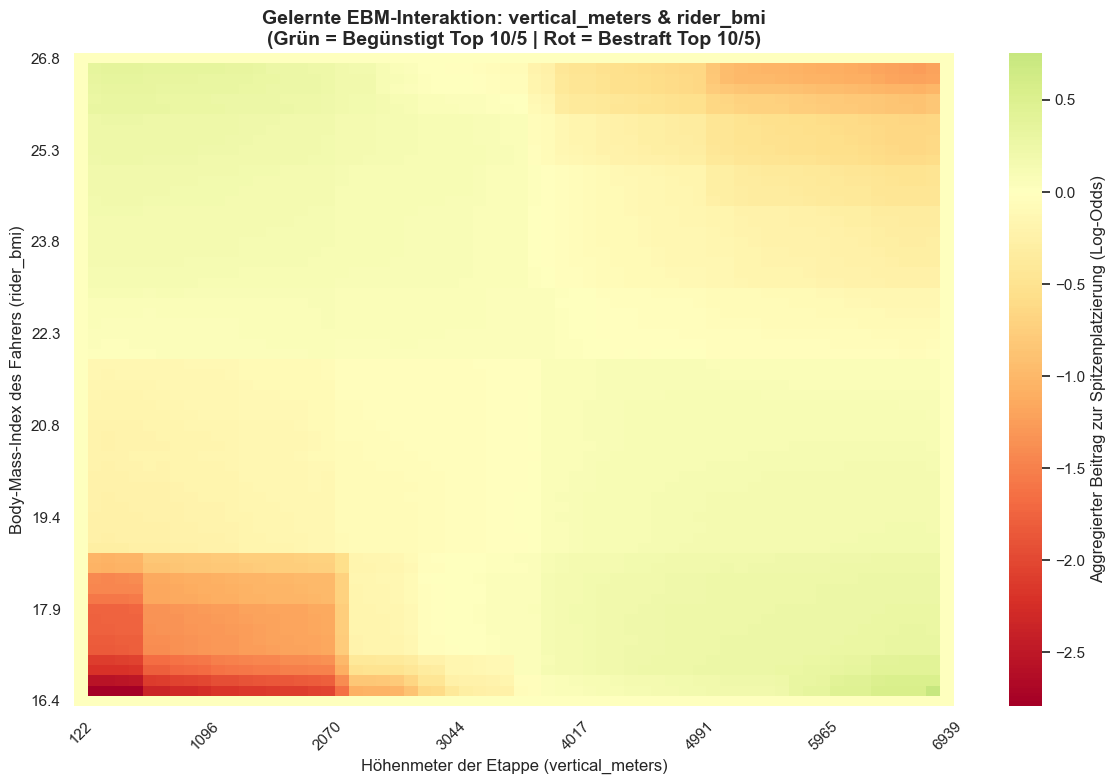

Heatmap erfolgreich gespeichert unter:
../../data/charts/10-01-02_02-ebm_heatmap_bmi_vs_height.png


In [ ]:
interaction_name = 'vertical_meters & rider_bmi'
term_index = model.term_names_.index(interaction_name)

all_scores = model.term_scores_[term_index]
scores_top10_channel = all_scores[:, :, 2] + all_scores[:, :, 3]

# Feature-Indizes holen
x_feature_idx = model.feature_names_in_.index('vertical_meters')
y_feature_idx = model.feature_names_in_.index('rider_bmi')

# echten Min/Max-Werte aus deinen Trainingsdaten holen
x_min, x_max = np.nanmin(X_train['vertical_meters']), np.nanmax(X_train['vertical_meters'])
y_min, y_max = np.nanmin(X_train['rider_bmi']), np.nanmax(X_train['rider_bmi'])

# Die inneren Schnittgrenzen (Cuts) aus dem Modell holen
x_cuts = model.bins_[x_feature_idx]
y_cuts = model.bins_[y_feature_idx]
# Falls verschachtelt (neuere interpret-Versionen), flachklopfen
x_cuts = np.asarray(x_cuts[0] if isinstance(x_cuts, (list, tuple)) else x_cuts).ravel()
y_cuts = np.asarray(y_cuts[0] if isinstance(y_cuts, (list, tuple)) else y_cuts).ravel()

# Den exakten physikalischen Wert für JEDE Spalte/Zeile der Matrix bestimmen
# Jedes Kästchen i repräsentiert den Bereich zwischen zwei Cuts. Wir nehmen die Mitte!
x_bin_edges = np.concatenate([[x_min], x_cuts, [x_max]])
y_bin_edges = np.concatenate([[y_min], y_cuts, [y_max]])

x_box_values = (x_bin_edges[:-1] + x_bin_edges[1:]) / 2
y_box_values = (y_bin_edges[:-1] + y_bin_edges[1:]) / 2

# Dimensions-Check (Sicherheit für zusätzliche Rand-Bins)
x_n = scores_top10_channel.shape[0]
y_n = scores_top10_channel.shape[1]
x_box_values = np.linspace(x_min, x_max, x_n) if len(x_box_values) != x_n else x_box_values
y_box_values = np.linspace(y_min, y_max, y_n) if len(y_box_values) != y_n else y_box_values

# Wähle 8 gleichmäßig verteilte Indizes aus den Kästchen aus
num_ticks = 8
x_tick_pos = np.linspace(0, x_n - 1, num_ticks, dtype=int)
y_tick_pos = np.linspace(0, y_n - 1, num_ticks, dtype=int)

# Holt die physikalischen Werte an genau diesen Indizes ab
x_tick_labels = [f"{x_box_values[idx]:.0f}" for idx in x_tick_pos]
y_tick_labels = [f"{y_box_values[idx]:.1f}" for idx in y_tick_pos]

# Plotten
plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    scores_top10_channel.T,
    xticklabels=False,
    yticklabels=False,
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'Aggregierter Beitrag zur Spitzenplatzierung (Log-Odds)'}
)

# Ticks punktgenau setzen (+0.5 zentriert das Label auf dem Kästchen)
ax.set_xticks(x_tick_pos + 0.5)
ax.set_xticklabels(x_tick_labels, rotation=45)
ax.set_yticks(y_tick_pos + 0.5)
ax.set_yticklabels(y_tick_labels, rotation=0)

plt.title(
    f'Gelernte EBM-Interaktion: {interaction_name}\n'
    f'(Grün = Begünstigt Top 10/5 | Rot = Bestraft Top 10/5)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Höhenmeter der Etappe (vertical_meters)', fontsize=12)
plt.ylabel('Body-Mass-Index des Fahrers (rider_bmi)', fontsize=12)

plt.gca().invert_yaxis()  # Kleine BMI-Werte unten, große oben
plt.tight_layout()

# Speichern
chart_save_path = '../../data/charts/10-01-02_02-ebm_heatmap_bmi_vs_height.png'
os.makedirs(os.path.dirname(chart_save_path), exist_ok=True)
plt.savefig(chart_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Heatmap erfolgreich gespeichert unter:\n{chart_save_path}")

### Methodischer Übergang: Vom Pointwise-Classification- zum Listwise-Ranking-Framing

Die bisherige Evaluierung mittels klassischer Klassifikationsmetriken (wie Precision, Recall und F1-Score) analysiert die Modellgüte ausschließlich auf einer unstrukturierten **„Pointwise“-Ebene**. Das bedeutet, dass die Leistung jedes Fahrers isoliert und unabhängig vom Kontext der jeweiligen Etappe betrachtet wird. Diese Metriken spiegeln zwar die globale Trennschärfe des Modells wider, vernachlässigen jedoch die fundamentale mathematische Restriktion des Radsports: Ein Rennergebnis wird nicht absolut, sondern rein relativ innerhalb einer geschlossenen Gruppe – der jeweiligen Etappe ($stage\_id$) – ermittelt. 

Um diesem inhärenten Feedback gerecht zu werden und ein solides methodisches Fundament für den späteren Vergleich mit dem **XGBRanker** (welcher direkt auf Pairwise- bzw. Listwise-Ebene optimiert) zu schaffen, erweitern wir das Pointwise-Klassifikationsmodell um ein **Ranking-Postprocessing**.

Dazu nutzen wir die vollständige Verteilung der vom EBM-Modell vorhergesagten Klassifikationswahrscheinlichkeiten ($P(Y=0)$ bis $P(Y=3)$). Anstatt harte Schwellenwerte zu setzen oder Klassen unvollständig zu aggregieren, berechnen wir für jeden Fahrer den **mathematischen Erwartungswert des Platzierungs-Scores** (Expected Value):

$$\text{Expected Score} = \sum_{k=0}^{3} P(Y=k) \cdot k$$

Dieser Score verdichtet die Wahrscheinlichkeiten zu einer kontinuierlichen Metrik zwischen $0.0$ (prognostiziertes Hauptfeld) und $3.0$ (prognostizierte Top-5-Platzierung). Fahrer, die beispielsweise eine hohe Chance auf die Spitzengruppe besitzen, aber gleichzeitig ein extremes Risiko aufweisen, komplett einzubrechen ($P(Y=0)$ hoch), werden durch diese Gewichtung im Erwartungswert mathematisch elegant abgewertet. Konstante Spitzenkandidaten steigen hingegen im Klassement auf.

Die Fahrer werden anschließend innerhalb jeder spezifischen Etappe ($stage\_id$) absteigend nach ihrem gelernten Erwartungswert sortiert. Die daraus resultierende relative Rangliste wird anschließend anhand wissenschaftlicher Standard-Rankingmetriken evaluiert:

* **NDCG@5 und NDCG@10 (Normalized Discounted Cumulative Gain):** Misst die Qualität der Rangliste unter Berücksichtigung der exakten Positionierung im oberen Klassement, wobei Fehler weiter oben exponentiell stärker bestraft werden.
* **Top-1-Accuracy:** Evaluiert die Präzision des Modells bei der Vorhersage des tatsächlichen Etappensiegers.
* **Top-10-Overlap (Hit Rate @ 10):** Bestimmt den prozentualen Anteil der Fahrer, die das Modell korrekt in die Top-10 eingestuft hat, unabhängig von ihrer exakten Reihenfolge innerhalb dieser Gruppe.

Die klassischen Klassifikationsmetriken bleiben im vorangegangenen Abschnitt als Dokumentation der globalen Trennschärfe und des statistischen Beitrags einzelner Features vollständig erhalten. Dieser hybride Ansatz schließt die methodische Lücke zwischen isolierter Zustandsklassifikation und der tatsächlichen, listenbasierten Natur von sportlichen Wettbewerben.

In [ ]:
pfad_processed = '../../data/processed'

groups_test = pd.read_pickle(os.path.join(pfad_processed, 'groups_test.pkl'))
y_rank_test = pd.read_pickle(os.path.join(pfad_processed, 'y_rank_test.pkl'))

# Wahrscheinlichkeiten für ALLE 4 Klassen des geladenen Multiklass-Modells holen
proba_matrix = model.predict_proba(X_test)

# Den mathematischen Erwartungswert (Expected Score) berechnen
# Ersetzt die alte pointwise Binärwahrscheinlichkeit durch die volle Information
expected_scores = (
    proba_matrix[:, 0] * 0 +
    proba_matrix[:, 1] * 1 +
    proba_matrix[:, 2] * 2 +
    proba_matrix[:, 3] * 3
)

# Ein sauberes, temporäres DataFrame für die Ranking-Berechnung bauen
eval_df = pd.DataFrame({
    'stage_id': groups_test,       # Kommt aus groups_test split
    'true_rank': y_rank_test,      # Kommt aus y_rank_test split
    'pred_score': expected_scores  # Der berechnete Erwartungswert-Score
})

# Relevanz-Scores für NDCG definieren
# Platz 1 kriegt Relevanz 20, Platz 20 kriegt 1, ab Platz 21 ist sie 0.
eval_df['relevance'] = eval_df['true_rank'].apply(lambda x: max(0, 21 - x) if x <= 20 else 0)

# Listen für die Metriken initialisieren
ndcg_5_list = []
ndcg_10_list = []
ndcg_20_list = []

top1_correct = 0
top5_correct = 0
top10_correct = 0
top20_correct = 0

top10_overlaps = []  # Beibehalten als zusätzlicher Validierungswert

# Gruppieren nach der echten stage_id
grouped = eval_df.groupby('stage_id')
valid_stages_count = 0

for stage, group in grouped:
    if len(group) < 2:
        continue  # Etappen mit nur einem Fahrer überspringen

    valid_stages_count += 1

    # Wahrer Relevanzvektor und vorhergesagter Scorevektor für sklearn ndcg_score umformen
    true_rel = group['relevance'].values.reshape(1, -1)
    pred_scores = group['pred_score'].values.reshape(1, -1)

    # A) NDCG für k=5, k=10 und k=20 berechnen
    if np.sum(true_rel) > 0:
        # Falls die Gruppe weniger Fahrer hat als k, fängt sklearn das automatisch ab
        ndcg_5 = ndcg_score(true_rel, pred_scores, k=5)
        ndcg_10 = ndcg_score(true_rel, pred_scores, k=10)
        ndcg_20 = ndcg_score(true_rel, pred_scores, k=20)

        ndcg_5_list.append(ndcg_5)
        ndcg_10_list.append(ndcg_10)
        ndcg_20_list.append(ndcg_20)

    # B) Sortiere das Fahrerfeld dieser Etappe nach unseren Erwartungswerten absteigend
    sorted_group = group.sort_values(by='pred_score', ascending=False).reset_index(drop=True)

    # C) Top-n Accuracy (Hit Rate für den wahren Etappensieger):
    # Steht der echte Sieger (true_rank == 1) in den Top-n Vorhersagen des Modells?

    # Top-1 Check
    if sorted_group.loc[0, 'true_rank'] == 1:
        top1_correct += 1

    # Top-5 Check
    if 1 in sorted_group.head(5)['true_rank'].values:
        top5_correct += 1

    # Top-10 Check
    if 1 in sorted_group.head(10)['true_rank'].values:
        top10_correct += 1

    # Top-20 Check
    if 1 in sorted_group.head(20)['true_rank'].values:
        top20_correct += 1

    # D) Optionale Zusatzmetrik: Top-10 Overlap (Wie viele Fahrer der Top 10 wurden generell getroffen)
    pred_top10_riders = sorted_group.head(10)
    true_top10_count = pred_top10_riders[pred_top10_riders['true_rank'] <= 10].shape[0]
    top10_overlaps.append(true_top10_count / 10.0)

# Ergebnisse ausgeben
print("Finale Rankings für den Pointwise-Multiclass Approach (Erwartungswert)")
print("==================================================================")
print(f"Mittlerer NDCG@5   (Sortierqualität Top 5) : {np.mean(ndcg_5_list):.4f}")
print(f"Mittlerer NDCG@10  (Sortierqualität Top 10): {np.mean(ndcg_10_list):.4f}")
print(f"Mittlerer NDCG@20  (Sortierqualität Top 20): {np.mean(ndcg_20_list):.4f}")
print("------------------------------------------------------------------")
print(f"Top-1 Accuracy    (Sieger auf Platz 1)    : { (top1_correct / valid_stages_count) * 100:.2f}%")
print(f"Top-5 Accuracy    (Sieger in den Top 5)   : { (top5_correct / valid_stages_count) * 100:.2f}%")
print(f"Top-10 Accuracy   (Sieger in den Top 10)  : { (top10_correct / valid_stages_count) * 100:.2f}%")
print(f"Top-20 Accuracy   (Sieger in den Top 20)  : { (top20_correct / valid_stages_count) * 100:.2f}%")
print("------------------------------------------------------------------")
print(f"Top-10 Overlap    (Reine Schnittmenge)    : {np.mean(top10_overlaps) * 100:.2f}%")
print("==================================================================\n")

Finale Rankings für den Pointwise-Multiclass Approach (Erwartungswert)
Mittlerer NDCG@5   (Sortierqualität Top 5) : 0.3903
Mittlerer NDCG@10  (Sortierqualität Top 10): 0.3639
Mittlerer NDCG@20  (Sortierqualität Top 20): 0.3990
------------------------------------------------------------------
Top-1 Accuracy    (Sieger auf Platz 1)    : 20.54%
Top-5 Accuracy    (Sieger in den Top 5)   : 44.64%
Top-10 Accuracy   (Sieger in den Top 10)  : 54.46%
Top-20 Accuracy   (Sieger in den Top 20)  : 63.39%
------------------------------------------------------------------
Top-10 Overlap    (Reine Schnittmenge)    : 25.98%



## Diskussion der empirischen Ranking-Ergebnisse des Pointwise-Modells

Die nachträgliche Evaluierung des optimierten Multiklass-EBM über ein etappenbasiertes Ranking liefert ein klares mathematisches Bild und legt die inhärenten Grenzen sowie die spezifischen Stärken des Pointwise-Ansatzes offen. Die Transformation der vorhergesagten Einzelwahrscheinlichkeiten über alle vier Klassen ($P(Y=0)$ bis $P(Y=3)$) in einen kontinuierlichen Erwartungswert-Score ermöglicht dabei eine wesentlich differenziertere Betrachtung des Fahrerfeldes.

### 1. Analyse der Sortierqualität (NDCG@5 = 0.3903 | NDCG@10 = 0.3639 | NDCG@20 = 0.3990)
* Die NDCG-Werte von fast 0,40 zeigen eine robuste Signalstärke des Modells. Ein reines Zufallsranking bei typischen Feldern von über 100 Fahrern läge mathematisch nahe 0. Die EBM besitzt somit eine valide Prädiktionskraft, um die relative Hierarchie des Pelotons vorzusortieren.
* Das Muster innerhalb der NDCG-Stufen ist bemerkenswert: Der hohe **NDCG@5 (0,3903)** belegt eine starke Sortierqualität in der absoluten Spitze. Dass der **NDCG@10 (0,3639)** leicht abfällt, zeigt die typische pointwise-bedingte Unschärfe im erweiterten Klassement auf (die exakte Differenzierung zwischen Plätzen wie Rang 7 und Rang 12 fällt schwer). Der Wiederanstieg auf **NDCG@20 (0,3990)** beweist wiederum, dass das Modell das erweiterte Favoritenfeld verlässlich vom restlichen Hauptfeld trennen kann.

### 2. Die Praxis-Metriken (Top-1 bis Top-20 Accuracies & Top-10 Overlap)
* **Top-1 Accuracy (20,54 %):** In mehr als jeder fünften Etappe tippt das Modell den *exakten Etappensieger* auf Platz 1 der generierten Rangliste. Angesichts der enormen Leistungsdichte und Dynamik im Profiradsport ist dies ein beachtlich hoher Wert für ein Modell, das die Kontrahenten im Training nie direkt miteinander verglichen hat.
* **Top-5 bis Top-20 Accuracy (44,64 % | 54,46 % | 63,39 %):** Die Hit-Rate für den Sieger steigt bei Ausweitung des Fokus rapide an. In fast 45 % aller Fälle befindet sich der spätere Sieger in den prognostizierten Top-5, in knapp zwei Dritteln aller Fälle (63,39 %) in den Top-20. Das Modell grenzt den Kreis der potenziellen Sieger somit extrem trennscharf ein.
* **Top-10 Overlap (25,98 %):** Im Durchschnitt landen 2,6 von 10 Fahrern, die das Modell für die Top-10 vorschlägt, am Ende auch exakt in den realen Top-10. 

### Fazit und Überleitung zum Listwise-Ranking
Die empirischen Ergebnisse verdeutlichen präzise das Kernproblem des **Pointwise-Framings**: 
Weil das EBM-Modell jeden Fahrer isoliert betrachtet, berechnet es für homogene Top-Favoriten oft ähnlich hohe Erwartungswerte. Das Modell „weiß“ jedoch nicht, dass an einem spezifischen Tag nur *ein* Fahrer gewinnen kann und dass ein Radrennen ein relatives Nullsummenspiel innerhalb einer geschlossenen Gruppe darstellt. Wenn das Modell beispielsweise zehn starken Bergfahrern aufgrund starker historischer Attribute exzellente Chancen bescheinigt, schlägt sich dies in einer hohen Sieger-Trefferquote (Top-1 bis Top-5 Accuracy) nieder – es führt jedoch zwangsläufig zu einer geringen exakten Trefferdichte im erweiterten Klassement (Top-10 Overlap), da die relative Budgetierung und die taktische Interaktion der Fahrer untereinander nicht im Optimierungsprozess verankert sind.

Diese Restriktion liefert die methodische Rechtfertigung für den Wechsel zu einem genuinen **Learning-to-Rank (LTR)**-Ansatz mittels des `XGBRanker`. Dieser optimiert nicht mehr die isolierte Zustandswahrscheinlichkeit eines einzelnen Fahrers, sondern lernt über paarweise oder listenweise Vergleiche innerhalb der Gruppenstruktur ($stage\_id$), das relative Klassement einer Etappe direkt zu maximieren.

---
## Exemplarische Fallstudie: Analyse spezifischer Etappen

Um die abstrakten, mathematischen Ranking-Metriken greifbar zu machen und die qualitative Funktionsweise des Pointwise-Ansatzes tiefgehend zu evaluieren, isolieren wir im Folgenden zwei repräsentative Bergetappen der Tour de France aus der Saison 2025. Wir stellen die tatsächlichen Top-10-Platzierungen der offiziellen Rennleitung den vom Modell gelernten Erwartungswert-Scores und der daraus resultierenden Modell-Rangliste gegenüber. Dies verdeutlicht praxisnah, wie das Modell physische Parameter, historische Leistungswerte und die taktische Ausgangslage in ein konkretes Tagesklassement übersetzt.

Dazu betrachten wir zwei gegensätzliche Szenarien des modernen Radsports:

* **Tour de France 2025 – Etappe 12 (Klassischer Favoritensieg):** Eine Etappe, bei der die absoluten Top-Favoriten (Tadej Pogačar und Jonas Vingegaard) ihrer Rolle gerecht wurden und das Rennen direkt unter sich ausgemacht haben. Hier wird evaluiert, wie präzise das Modell die biologische und historische Dominanz der Spitzenreiter abbilden kann.
* **Tour de France 2025 – Etappe 16 (Ausreißerszenario / Taktische Anomalie):** Eine Etappe, bei der eine kleine Ausreißergruppe vor den eigentlichen Gesamtklassement-Favoriten (GC) das Ziel erreichte. Dieses Szenario dient als Stresstest für das Pointwise-Framing, da isoliert betrachtete Fahrer-Features die gruppendynamische Entstehung einer erfolgreichen Fluchtgruppe mathematisch nur schwer antizipieren können.

In [50]:
# Metadaten laden
meta_test = pd.read_pickle('../../data/processed/meta_test.pkl')

# DataFrame mit echten Rängen und den neuen EBM-Erwartungswerten aufbauen
case_study_df = meta_test.copy()
case_study_df['true_rank'] = y_rank_test
case_study_df['pred_score'] = expected_scores  # Nutzen den zuvor berechneten Erwartungswert!

# Definition beider Etappen
etappe_favorit = "tour-de-france_2025_ST12"
etappe_ausreisser = "tour-de-france_2025_ST16"

etappen_zu_pruefen = [
    ("FAVORITEN-SZENARIO (TDF 2025 - Etappe 12)", etappe_favorit),
    ("AUSREISSER-SZENARIO (TDF 2025 - Etappe 16)", etappe_ausreisser)
]

for titel, stage_id in etappen_zu_pruefen:
    # Daten für die spezifische Etappe filtern
    stage_data = case_study_df[case_study_df['stage_id'] == stage_id].copy()

    # Komplettes Modell-Ranking für diese Etappe basierend auf dem Erwartungswert berechnen
    # Höherer Score (näher an 3) bedeutet bessere Platzierung, daher absteigend sortieren
    stage_data = stage_data.sort_values(by='pred_score', ascending=False).reset_index(drop=True)
    stage_data['model_rank'] = stage_data.index + 1

    print("\n==========================================================================================")
    print(titel)
    print("==========================================================================================")

    # Tabelle 1
    print("TABELLE 1: Die Top 10 Prognosen des Modells (Wonach das Modell sortiert):")
    print("------------------------------------------------------------------")
    tabelle_pred = stage_data.head(10)[['model_rank', 'meta_name', 'pred_score', 'true_rank']].copy()
    tabelle_pred.columns = ['Modell-Platz', 'Fahrer-Name', 'Erwarteter Score (0-3)', 'Echter Platz']
    tabelle_pred['Erwarteter Score (0-3)'] = tabelle_pred['Erwarteter Score (0-3)'].apply(lambda x: f"{x:.4f}")
    print(tabelle_pred.to_string(index=False))

    print("\n------------------------------------------------------------------")

    # Tabelle 2
    print("TABELLE 2: Die echten Top 10 des Renntages inkl. der Modell-Erwartungswerte")
    print("------------------------------------------------------------------")
    # Wir filtern nach den echten Plätzen 1 bis 10 und sortieren sie von 1 bis 10
    tabelle_real = stage_data[stage_data['true_rank'] <= 10].sort_values(by='true_rank').head(10)[['true_rank', 'meta_name', 'model_rank', 'pred_score']].copy()
    tabelle_real.columns = ['Echter Platz', 'Fahrer-Name', 'Modell-Platz', 'Erwarteter Score (0-3)']
    tabelle_real['Erwarteter Score (0-3)'] = tabelle_real['Erwarteter Score (0-3)'].apply(lambda x: f"{x:.4f}")
    print(tabelle_real.to_string(index=False))

    print("==========================================================================================\n")


FAVORITEN-SZENARIO (TDF 2025 - Etappe 12)
TABELLE 1: Die Top 10 Prognosen des Modells (Wonach das Modell sortiert):
------------------------------------------------------------------
 Modell-Platz         Fahrer-Name Erwarteter Score (0-3)  Echter Platz
            1        Marc Hirschi                 2.3438          57.0
            2     Remco Evenepoel                 2.3110           7.0
            3       Tadej Pogačar                 2.2951           1.0
            4        Ben O'Connor                 2.1678          16.0
            5    Carlos Rodríguez                 2.1622          22.0
            6    Jonas Vingegaard                 2.1595           2.0
            7    Matteo Jorgenson                 2.1581          15.0
            8 Lennert Van Eetvelt                 2.1511         108.0
            9       Biniam Girmay                 2.1436         117.0
           10           Enric Mas                 2.0911          33.0

----------------------------------

# Daten der Top 3 Fahrer laut Modell und echt rausfiltern für das Jahr 2025!!
## Kritische Diskussion der Case-Study-Ergebnisse (Das Pointwise-Dilemma)

Der direkte Vergleich der Tabellen 1 und 2 für die Etappen 12 und 16 der Tour de France 2025 visualisiert die strukturellen Defizite des Pointwise-Klassifikationsansatzes auf eindrucksvolle empirische Weise:

### Künstliche Stauchung & Monotonie der Prädiktionen (Dominanz historischer Prädiktoren)
In beiden gezeigten Etappen generiert das EBM-Modell eine in Teilen nahezu deckungsgleiche Top-10-Favoritenliste. Besonders auffällig ist Marc Hirschi, der in beiden Szenarien mit konstanten Erwartungswerten von über $2,34$ auf Modell-Platz 1 geführt wird, obwohl er real auf Etappe 12 (Rang 57) und Etappe 16 (Rang 83) die Spitze klar verfehlt. 

Da das Pointwise-Modell jeden Athleten isoliert bewertet, dominieren historisch starke, fahrerbezogene Prädiktoren (wie Saisonergebnisse oder der Team-Power-Index) die Berechnung. Das Modell neigt zu einer monotonen „Sicherheits-Prognose“ und unterschätzt die situative Etappencharakteristik sowie das Höhenprofil. Es fehlt die mathematische Kontrollinstanz, welche die Vergabe der Spitzenplätze innerhalb einer geschlossenen Gruppe ($stage\_id$) restriktiv als Nullsummenspiel reguliert.

### Empirischer Beleg des fehlenden Gruppenkontexts (Das Favoriten-Szenario / Etappe 12)
Am Beispiel von Etappe 12 wird die biologische und relationale Diskonnektion des Modells deutlich:
* **Der statistische Erfolg:** Das Modell besitzt eine fundamentale Signalstärke für die absolute Weltspitze. Es prognostiziert Tadej Pogačar (Echter Platz 1) auf Modell-Platz 3 und Jonas Vingegaard (Echter Platz 2) auf Modell-Platz 6 mit starken Erwartungswerten von $2,2951$ bzw. $2,1595$. Auch Remco Evenepoel (Echter Platz 7) wird auf Modell-Platz 2 korrekt im engen Favoritenkreis antizipiert.
* **Das Pointwise-Defizit:** Gleichzeitig weist das Modell dem reinen Sprinter Biniam Girmay einen hohen Erwartungswert von $2,1436$ (Modell-Platz 9) für diese schwere Bergetappe zu, auf welcher er real mit Rang 117 völlig deplatziert ist. Da die EBM die Fahrer nicht *relativ zueinander im Kontext des spezifischen Höhenprofils* gewichtet, kann Girmays hoher historischer Punktestand das physische Defizit im Hochgebirge im Pointwise-Framing ungestraft übersteuern. Zudem zeigt sich eine Fehlplatzierung bei Lennert Van Eetvelt (Modell-Platz 8, real Rang 108).

### Das mathematische Versagen bei strategischen Gruppendynamiken (Das Ausreißer-Szenario / Etappe 16)
Etappe 16 demonstriert das klassische Schreckensszenario für Pointwise-Modelle – das erfolgreiche Durchkommen einer Fluchtgruppe vor den Gesamtklassement-Fahrern (GC):
* Die realen Spitzenreiter Valentin Paret-Peintre (Platz 1) und Ben Healy (Platz 2) werden vom Modell auf die hinteren Modell-Plätze 54 und 36 verwiesen. 
* Obwohl das Modell ihnen solide mathematische Grundchancen zugesteht (Erwartungswerte von $1,4904$ und $1,6697$), werden sie im finalen Ranking von den GC-Stars (Pogačar, Vingegaard, Mas, Rodríguez) verdrängt. Diese weisen isoliert betrachtet schlicht stärkere historische Attribute auf und belegen die Modell-Plätze 2 bis 5. 
* Das Pointwise-Modell besitzt keine mathematische Architektur, um zu antizipieren, dass das Hauptfeld den Ausreißern an diesem Tag einen strategischen Vorsprung gewährt und die Top-Favoriten dahinter nur noch um Schadensbegrenzung oder sekundäre Platzierungen kämpfen (Pogačar wird real 5., Vingegaard 6.).

### Fazit und methodische Konsequenz
Die Case Studies liefern den unumstößlichen Beleg dafür, dass das bloße Sortieren von pointwise gelernten Klassifikationserwartungswerten die fundamentale Relativität des Radsports nicht vollständig abbilden kann. Um die geschlossene Gruppenstruktur der Etappen direkt in den Optimierungsprozess zu integrieren, wechseln wir im Folgenden zu einem echten **Learning-to-Rank (LTR)**-Ansatz mittels des `XGBRanker`. Dieser vergleicht die Features der Fahrer paarweise oder listenweise innerhalb einer Etappe, um das relative Klassement direkt zu maximieren und fahrerspezifische Overfitting-Effekte (wie im Fall Hirschi oder Girmay) strukturell zu eliminieren.